In [4]:
# Cell 1 — mount Drive and copy dataset into /content/dataset for faster access
from google.colab import drive
drive.mount('/content/drive')

# Adjust src_folder if your dataset is in a subfolder of the given path
src_folder = "/content/drive/MyDrive/LeukemiaAttri_Dataset"
dst_folder = "/content/dataset"

# Copy dataset (this will create /content/dataset/LeukemiaAttri_Dataset)
!mkdir -p "{dst_folder}"
!cp -r "{src_folder}" "{dst_folder}/" || echo "Copy failed — check the src_folder path"

# Quick listing of the top-level to confirm
!ls -la "{dst_folder}"
!echo "Contents of LeukeimiaAttri_Dataset (sample):"
!ls -la "{dst_folder}/LeukemiaAttri_Dataset" | head -n 40


Mounted at /content/drive
total 12
drwxr-xr-x 2 root root 4096 Nov 26 22:27 .
drwxr-xr-x 1 root root 4096 Nov 26 22:27 ..
lrwxrwxrwx 1 root root   94 Nov 26 22:27 LeukemiaAttri_Dataset -> /content/drive/.shortcut-targets-by-id/1J5ld-tK6cewj9wXWUi3rs6UdlHnDBe8U/LeukemiaAttri_Dataset
Contents of LeukeimiaAttri_Dataset (sample):
lrwxrwxrwx 1 root root 94 Nov 26 22:27 /content/dataset/LeukemiaAttri_Dataset -> /content/drive/.shortcut-targets-by-id/1J5ld-tK6cewj9wXWUi3rs6UdlHnDBe8U/LeukemiaAttri_Dataset


In [5]:
# STEP 1 — set paths & verify

import os, glob, json

BASE = "/content/dataset/LeukemiaAttri_Dataset/H_100X_C2"

TRAIN_JSON = f"{BASE}/json_labels/train.json"
TEST_JSON  = f"{BASE}/json_labels/test.json"

IMG_DIR_TRAIN = f"{BASE}/Images/train"
IMG_DIR_TEST  = f"{BASE}/Images/test"

print("train.json:", os.path.exists(TRAIN_JSON), TRAIN_JSON)
print("test.json :", os.path.exists(TEST_JSON), TEST_JSON)

print("\nTrain images count:", len(os.listdir(IMG_DIR_TRAIN)))
print("Test images count :", len(os.listdir(IMG_DIR_TEST)))

print("\nSample train images:", sorted(os.listdir(IMG_DIR_TRAIN))[:10])
print("\nSample test images :", sorted(os.listdir(IMG_DIR_TEST))[:10])

train.json: True /content/dataset/LeukemiaAttri_Dataset/H_100X_C2/json_labels/train.json
test.json : True /content/dataset/LeukemiaAttri_Dataset/H_100X_C2/json_labels/test.json

Train images count: 1677
Test images count : 692

Sample train images: ['10_10_1000_ALL.png', '10_11_1000_ALL.png', '10_12_1000_ALL.png', '10_13_1000_ALL.png', '10_14_1000_ALL.png', '10_15_1000_ALL.png', '10_16_1000_ALL.png', '10_17_1000_ALL.png', '10_18_1000_ALL.png', '10_1_1000_ALL.png']

Sample test images : ['15_10_1000_AML.png', '15_11_1000_AML.png', '15_12_1000_AML.png', '15_14_1000_AML.png', '15_15_1000_AML.png', '15_16_1000_AML.png', '15_17_1000_AML.png', '15_18_1000_AML.png', '15_19_1000_AML.png', '15_1_1000_AML.png']


In [6]:
IMAGE_DIR = "/content/dataset/LeukemiaAttri_Dataset/H_100X_C2/Images/train"
TRAIN_JSON = "/content/dataset/LeukemiaAttri_Dataset/H_100X_C2/json_labels/train.json"


In [7]:
import json, os, math
from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

# numeric morphological features
num_cols = [
    "cell_size","nuclear_chromation","nuclear_shape","nucleolus",
    "cytoplasm","cytoplasmic_basophilia","cytoplasmic_vacuoles"
]

# load JSON
with open(TRAIN_JSON, "r") as f:
    j = json.load(f)

images = {img['id']: img for img in j['images']}
ann_by_image = defaultdict(list)
for ann in j['annotations']:
    ann_by_image[ann['image_id']].append(ann)

# storage
clean_images = []
clean_annotations = []
missing_files = []
images_no_ann = []
new_ann_id = 1

for img_id, img in images.items():
    fname = img["file_name"]
    img_path = Path(IMAGE_DIR) / fname

    if not img_path.exists():
        missing_files.append((img_id, fname))

    anns = ann_by_image.get(img_id, [])
    if len(anns) == 0:
        images_no_ann.append(img_id)

    kept = []
    for a in anns:
        cname = str(a.get("category_name","")).strip().lower()
        if cname in ["none","", "null"]:
            continue

        a2 = dict(a)
        a2["category_name"] = cname

        # fix sentinel numeric value = 4 → missing
        for c in num_cols:
            if c in a2 and a2[c] == 4:
                a2[c] = None

        a2["id"] = new_ann_id
        new_ann_id += 1

        kept.append(a2)
        clean_annotations.append(a2)

    if len(kept) > 0:
        clean_images.append(img)

clean_json = {
    "images": clean_images,
    "annotations": clean_annotations,
    "categories": j.get("categories", [])
}

with open("/content/train_clean.json", "w") as f:
    json.dump(clean_json, f, indent=2)

print("Saved cleaned JSON → /content/train_clean.json")
print("Missing image files:", len(missing_files))
print("Images with no valid annotations:", len(images_no_ann))


Saved cleaned JSON → /content/train_clean.json
Missing image files: 0
Images with no valid annotations: 0


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import json

with open("/content/train_clean.json", "r") as f:
    cj = json.load(f)

# Corrected num_cols to fix the typo from 'nuclear_chromation' to 'nuclear_chromatio'
# as identified from the previous cell's kernel state (variable 'a2').
num_cols = [
    "cell_size","nuclear_chromatio","nuclear_shape","nucleolus",
    "cytoplasm","cytoplasmic_basophilia","cytoplasmic_vacuoles"
]

rows = []
for ann in cj["annotations"]:
    rows.append([ann.get(c) for c in num_cols])

arr = np.array(rows, dtype=float)

# impute missing numerics
imp = SimpleImputer(strategy="median")
arr_imputed = imp.fit_transform(arr)

# standardize numerics
scaler = StandardScaler()
arr_scaled = scaler.fit_transform(arr_imputed)

# write imputed back
idx = 0
for ann in cj["annotations"]:
    for j, c in enumerate(num_cols):
        ann[c] = float(arr_imputed[idx, j])
    idx += 1

with open("/content/train_clean_imputed.json", "w") as f:
    json.dump(cj, f, indent=2)

print("Saved → /content/train_clean_imputed.json")


Saved → /content/train_clean_imputed.json


In [9]:
# ---------- Graph building with NetworkX ----------
import json, os, random, math
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from tqdm import tqdm

import networkx as nx
import pickle
import torch

# --------- EDIT PATHS IF NEEDED ----------
CLEAN_IMPUTED_JSON = "/content/train_clean_imputed.json"
IMAGE_DIR = "/content/dataset/LeukemiaAttri_Dataset/H_100X_C2/Images/train"
OUTPUT_NX = "/content/aml_graphs_networkx.pkl"
K_KNN = 6
USE_KNN = True
EPS = 1e-6
RANDOM_STATE = 42
# -----------------------------------------

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Load cleaned + imputed JSON
with open(CLEAN_IMPUTED_JSON, "r") as f:
    cj = json.load(f)

images = {img['id']: img for img in cj['images']}
ann_by_image = defaultdict(list)
for ann in cj['annotations']:
    ann_by_image[ann['image_id']].append(ann)

print(f"Images in cleaned JSON: {len(images)}")
print(f"Annotations in cleaned JSON: {len(cj['annotations'])}")

# --------- Identify AML vs non-AML ----------
# Identify AML images (positive class)
aml_ids = [img_id for img_id, img in images.items() if "_aml" in img['file_name'].lower()]
aml_ids_set = set(aml_ids) # Use a set for efficient lookup

# Identify potential non-AML images (negative class candidates)
# These are images whose filenames contain other specified leukemia types, and are explicitly NOT AML.
other_leukemia_keywords = ["_cll", "_cml", "_ampl", "all"]
potential_non_aml_candidates = [
    img_id for img_id, img in images.items()
    if any(sub in img['file_name'].lower() for sub in other_leukemia_keywords) and img_id not in aml_ids_set
]

# The pool for truly non-AML images, ensuring no overlap with AML.
non_aml_ids_pool = potential_non_aml_candidates

print(f"Found {len(aml_ids)} AML images, {len(non_aml_ids_pool)} truly non-AML images available for selection.")

# Balance dataset: select an equal number of non-AML images as AML images
random.shuffle(non_aml_ids_pool)
num_pos = len(aml_ids) # The number of positive samples (AML images)

selected_pos = aml_ids # All AML images are used as positive samples.
# Select an equal number of non-AML images as negative samples, up to the available count.
selected_neg = non_aml_ids_pool[:num_pos] if len(non_aml_ids_pool) >= num_pos else non_aml_ids_pool

# The final list of unique image IDs to be processed for graph creation.
selected_image_ids = list(set(selected_pos + selected_neg))

# Construct the labels map for all selected unique images.
# This ensures that each unique image ID gets a consistent label.
labels_map = {img_id: (1 if img_id in aml_ids_set else 0) for img_id in selected_image_ids}

print(f"Using {len(selected_pos)} AML (label 1) and {len(selected_neg)} non-AML (label 0). Total unique images: {len(selected_image_ids)}")

# --------- Prepare encoders/scalers ----------
cat_list = []
num_list = []
num_cols = [
    "cell_size","nuclear_chromatio","nuclear_shape","nucleolus",
    "cytoplasm","cytoplasmic_basophilia","cytoplasmic_vacuoles"
]

# Only use annotations from the finally selected unique images for scaler/encoder fitting
for img_id in selected_image_ids:
    for a in ann_by_image.get(img_id, []):
        cat_list.append(a.get('category_name', 'unknown'))
        num_list.append([a.get(c) for c in num_cols])

# One-hot for categories
cat_unique = sorted(set(cat_list))
print("Detected categories:", cat_unique)

oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
oh.fit(np.array(cat_unique).reshape(-1,1))

# numeric features imputing & scaling
num_arr = np.array(num_list, dtype=float)
num_arr[num_arr == 4.0] = np.nan
col_meds = np.nanmedian(num_arr, axis=0)

inds = np.where(np.isnan(num_arr))
for r,c in zip(*inds):
    num_arr[r,c] = col_meds[c] if not np.isnan(col_meds[c]) else 0.0

scaler = StandardScaler()
scaler.fit(num_arr)

# --------- node-features helper ----------
def build_nodes_and_features(anns):
    coords, cats, num_feats = [], [], []

    for a in anns:
        x_bbox,y_bbox,w,h = a['bbox']
        cx = x_bbox + w/2.0
        cy = y_bbox + h/2.0

        coords.append([cx, cy])
        cats.append([a.get('category_name', 'unknown')])

        nf = [a.get(c) for c in num_cols]
        nf = [(np.nan if (v is None or v == 4) else v) for v in nf]
        nf = [(col_meds[i] if np.isnan(v) else v) for i,v in enumerate(nf)]
        num_feats.append(nf)

    if len(coords) == 0:
        return None, None, None

    coords = np.array(coords, dtype=float)
    num_feats = np.array(num_feats, dtype=float)
    num_feats = scaler.transform(num_feats)
    cat_oh = oh.transform(np.array(cats))

    x = np.hstack([cat_oh, num_feats]).astype(np.float32)
    return coords, x, anns


# ---------- NetworkX Graph Building ----------

# 1) Reset counters
nx_graphs = []
missing_images = []
zero_node_images = []

print("\n========== Building NetworkX Graphs ==========")
for img_id in tqdm(selected_image_ids, desc="Building NetworkX graphs"):
    anns = ann_by_image.get(img_id, [])
    if len(anns) == 0:
        missing_images.append(img_id)
        continue

    # Build node features
    coords, x, anns_for_img = build_nodes_and_features(anns)
    if coords is None or x is None or coords.shape[0] == 0:
        zero_node_images.append(img_id)
        continue

    n = coords.shape[0]
    dists = euclidean_distances(coords, coords)

    G = nx.Graph()
    # Add nodes
    for i in range(n):
        # Store both features (x) and explicit coordinates (pos_coords) in the node
        G.add_node(i, x=x[i], pos_coords=coords[i],
                   category=anns_for_img[i].get('category_name','unknown'),
                   cell_size=anns_for_img[i]['cell_size'])

    # Add edges
    if USE_KNN:
        k = min(K_KNN, max(1, n-1))
        for i in range(n):
            order = np.argsort(dists[i])
            nbrs = order[1:k+1]  # skip self
            for j in nbrs:
                if i == j:
                    continue
                w = 1.0 / (dists[i,j] + EPS)
                mult = 1.0 if anns_for_img[i].get('category_name') == anns_for_img[j].get('category_name') else 0.5
                w *= mult
                G.add_edge(i, j, weight=w)
    else:
        for i in range(n):
            for j in range(n):
                if i==j: continue
                w = 1.0 / (dists[i,j] + EPS)
                mult = 1.0 if anns_for_img[i].get('category_name') == anns_for_img[j].get('category_name') else 0.5
                w *= mult
                G.add_edge(i, j, weight=w)

    # Assign label
    G.graph['y'] = labels_map[img_id]
    G.graph['img_id'] = img_id
    G.graph['file_name'] = images[img_id]['file_name']

    nx_graphs.append(G)

# Save NetworkX graphs
OUTPUT_NX = "/content/aml_graphs_networkx.pkl"
with open(OUTPUT_NX, "wb") as f:
    pickle.dump(nx_graphs, f)

# Summary
from collections import Counter
y_all = [G.graph['y'] for G in nx_graphs]
print("\n========== Summary ==========")
print(f"Built NetworkX graphs: {len(nx_graphs)}")
print(f"Missing images: {len(missing_images)}")
print(f"Zero-node skipped: {len(zero_node_images)}")

# --------- Save Dataset ----------
pickle.dump(nx_graphs, open(OUTPUT_NX, "wb"))
print("Saved NetworkX graphs to:", OUTPUT_NX)

# --------- Label Distribution ----------
labels = [G.graph['y'] for G in nx_graphs]
print("Label distribution:", Counter(labels))


Images in cleaned JSON: 1609
Annotations in cleaned JSON: 5855
Found 734 AML images, 831 truly non-AML images available for selection.
Using 734 AML (label 1) and 734 non-AML (label 0). Total unique images: 1468
Detected categories: ['abnormal promyelocyte', 'atypical lymphocyte', 'basophil', 'eosinophil', 'lymphoblast', 'lymphocyte', 'metamyelocyte', 'monoblast', 'monocyte', 'myeloblast', 'myelocyte', 'neutrophil', 'promonocyte']

========== Building NetworkX Graphs ==========


Building NetworkX graphs: 100%|██████████| 1468/1468 [00:02<00:00, 680.86it/s]



========== Summary ==========
Built NetworkX graphs: 1468
Missing images: 0
Zero-node skipped: 0
Saved NetworkX graphs to: /content/aml_graphs_networkx.pkl
Label distribution: Counter({0: 734, 1: 734})


In [10]:
import pickle
graphs = pickle.load(open("/content/aml_graphs_networkx.pkl","rb"))

count = 0
for g in graphs:
    print(g.graph["img_id"], g.graph["file_name"], g.graph["y"])
    count += 1
    if count == 10:
        break

0 1_11_1000_ALL.png 0
1 1_15_1000_ALL.png 0
2 1_16_1000_ALL.png 0
3 1_26_1000_ALL.png 0
4 1_28_1000_ALL.png 0
5 1_32_1000_ALL.png 0
7 1_36_1000_ALL.png 0
8 1_37_1000_ALL.png 0
9 1_39_1000_ALL.png 0
10 1_41_1000_ALL.png 0


In [11]:
import pandas as pd

# Function to compute graph metrics
def graph_metrics(G):
    metrics = {}
    metrics['num_nodes'] = G.number_of_nodes()
    metrics['num_edges'] = G.number_of_edges()
    metrics['density'] = nx.density(G)

    # Degree stats
    degrees = [d for n,d in G.degree()]
    metrics['deg_mean'] = np.mean(degrees)
    metrics['deg_std'] = np.std(degrees)
    metrics['deg_min'] = np.min(degrees)
    metrics['deg_max'] = np.max(degrees)

    # Clustering coefficient
    metrics['clustering_mean'] = np.mean(list(nx.clustering(G).values()))

    # Connected component analysis
    if nx.is_connected(G):
        metrics['diameter'] = nx.diameter(G)
        metrics['avg_shortest_path'] = nx.average_shortest_path_length(G)
    else:
        largest_cc = G.subgraph(max(nx.connected_components(G), key=len))
        metrics['diameter'] = nx.diameter(largest_cc)
        metrics['avg_shortest_path'] = nx.average_shortest_path_length(largest_cc)

    metrics['label'] = G.graph['y']
    metrics['file_name'] = G.graph['file_name']
    return metrics

# Compute metrics for all graphs
graph_features = [graph_metrics(G) for G in nx_graphs]

# Convert to DataFrame for nice printing
df_metrics = pd.DataFrame(graph_features)
print("\n=== Graph Metrics Summary ===")
print(df_metrics.describe(include='all'))



=== Graph Metrics Summary ===
         num_nodes    num_edges      density     deg_mean      deg_std  \
count   1468.00000  1468.000000  1468.000000  1468.000000  1468.000000   
unique         NaN          NaN          NaN          NaN          NaN   
top            NaN          NaN          NaN          NaN          NaN   
freq           NaN          NaN          NaN          NaN          NaN   
mean       3.56812     7.284741     0.727264     2.388374     0.093202   
std        2.77099    10.950063     0.432119     2.275034     0.328024   
min        1.00000     0.000000     0.000000     0.000000     0.000000   
25%        1.00000     0.000000     0.000000     0.000000     0.000000   
50%        3.00000     3.000000     1.000000     2.000000     0.000000   
75%        5.00000    10.000000     1.000000     4.000000     0.000000   
max       20.00000    71.000000     1.000000     8.000000     2.126196   

            deg_min      deg_max  clustering_mean     diameter  \
count   1468.0

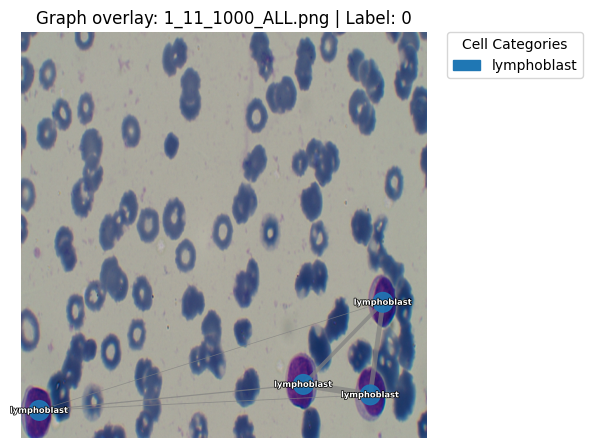

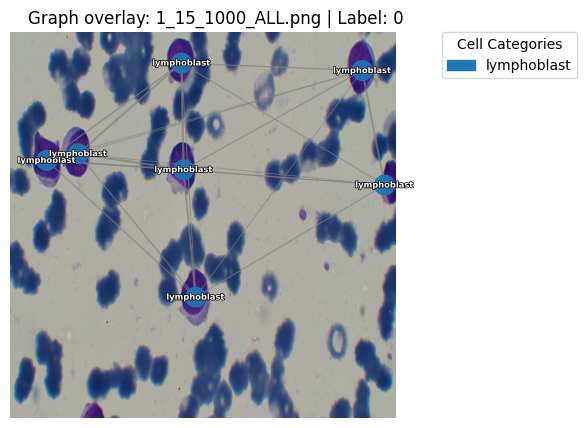

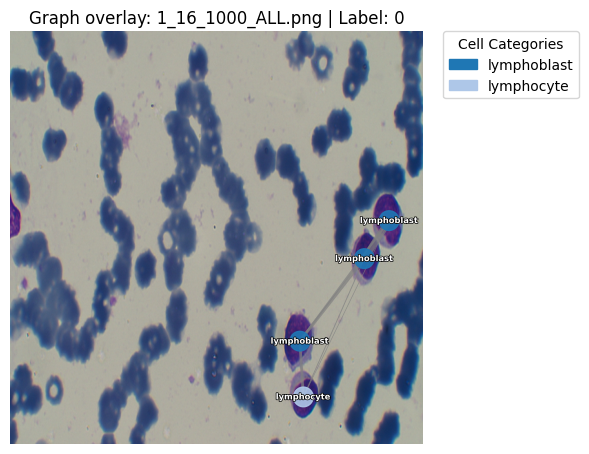

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import networkx as nx
import os
import matplotlib.patches as mpatches # For legend handles
import matplotlib.patheffects as patheffects # For text effects

def plot_graph_on_image(G, img_dir, figsize=(6,6)): # Increased figsize for legend
    img_path = os.path.join(img_dir, G.graph['file_name'])
    img = Image.open(img_path)

    plt.figure(figsize=figsize)
    ax = plt.gca() # Get current axes for legend placement
    plt.imshow(img)

    pos = {i: G.nodes[i]['pos_coords'] for i in G.nodes}

    # 1. Color nodes by cell category
    current_categories = [G.nodes[node_idx]['category'] for node_idx in G.nodes]
    unique_categories_in_graph = sorted(list(set(current_categories)))

    # Fix for MatplotlibDeprecationWarning
    colors = plt.colormaps.get_cmap('tab20')
    category_to_color = {cat: colors(i) for i, cat in enumerate(unique_categories_in_graph)}

    node_colors = [category_to_color[G.nodes[node_idx]['category']] for node_idx in G.nodes]

    # 2. Vary node sizes by cell_size
    node_raw_sizes = [G.nodes[node_idx]['cell_size'] for node_idx in G.nodes]
    scaled_node_sizes = []
    if node_raw_sizes:
        min_size_val = min(node_raw_sizes)
        max_size_val = max(node_raw_sizes)
        if max_size_val == min_size_val:
            scaled_node_sizes = [200 for _ in node_raw_sizes] # Default size if all are same
        else:
            # Scale sizes to a range, e.g., 100 to 800 for better visibility
            scaled_node_sizes = [100 + 700 * (s - min_size_val) / (max_size_val - min_size_val) for s in node_raw_sizes]

    # 3. Vary edge width by edge weight
    edge_weights = [G[u][v]['weight'] for u, v in G.edges(data=False)]
    scaled_edge_widths = []
    if edge_weights:
        min_weight = min(edge_weights)
        max_weight = max(edge_weights)
        if max_weight == min_weight:
            scaled_edge_widths = [1.0 for _ in edge_weights] # Default width
        else:
            # Scale widths to a range, e.g., 0.5 to 5.0
            scaled_edge_widths = [0.5 + 4.5 * (w - min_weight) / (max_weight - min_weight) for w in edge_weights]

    # Draw edges with varying widths
    nx.draw_networkx_edges(G, pos, alpha=0.7, edge_color='gray', width=scaled_edge_widths, ax=ax)

    # Draw nodes with varying colors and sizes
    nx.draw_networkx_nodes(G, pos, node_size=scaled_node_sizes, node_color=node_colors, alpha=0.9, ax=ax)

    # Add category labels to nodes for clarity
    for node_idx, coords in pos.items():
        category = G.nodes[node_idx].get('category', 'unknown')
        ax.text(coords[0], coords[1], category, fontsize=6, color='white', ha='center', va='center',
                weight='bold', path_effects=[patheffects.withStroke(linewidth=1, foreground='black')])

    plt.title(f"Graph overlay: {G.graph['file_name']} | Label: {G.graph['y']}")
    plt.axis('off')

    # Create and place legend for node colors
    legend_handles = [mpatches.Patch(color=category_to_color[cat], label=cat)
                      for cat in unique_categories_in_graph]

    ax.legend(handles=legend_handles, title='Cell Categories', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()
    plt.close() # Explicitly close the figure to free up memory and ensure clear display

# Example: visualize first 3 graphs
for i in range(3):
    plot_graph_on_image(nx_graphs[i], IMAGE_DIR)


In [13]:
import torch

def nx_to_tensors(G):
    # Node features
    x = torch.tensor([G.nodes[i]['x'] for i in G.nodes], dtype=torch.float)

    # Edge index
    edges = list(G.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2,0), dtype=torch.long)
        edge_attr = torch.empty((0,1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor([G[u][v]['weight'] for u,v in edges], dtype=torch.float).unsqueeze(1)

    # Label
    y = torch.tensor([G.graph['y']], dtype=torch.long)

    return x, edge_index, edge_attr, y

# Example for first graph
x, edge_index, edge_attr, y = nx_to_tensors(nx_graphs[0])
print(x.shape, edge_index.shape, edge_attr.shape, y)


torch.Size([4, 20]) torch.Size([2, 6]) torch.Size([6, 1]) tensor([0])


/tmp/ipython-input-2836790902.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor([G.nodes[i]['x'] for i in G.nodes], dtype=torch.float)


In [14]:
# ---------- Convert all NX graphs to tensors ----------
graph_tensors = []
for G in nx_graphs:
    x, edge_index, edge_attr, y = nx_to_tensors(G)
    graph_tensors.append({
        'x': x,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'y': y
    })

print(f"Total graphs ready: {len(graph_tensors)}")


Total graphs ready: 1468


In [64]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.3.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.3.0+cpu.html


In [18]:
# -------- Convert NetworkX graphs to PyG Data objects --------
pyg_data_list = []

for G in nx_graphs:
    x = torch.tensor([G.nodes[n]['x'] for n in G.nodes], dtype=torch.float)

    # Modified: Handle graphs with zero edges
    if len(G.edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor([G.edges[e]['weight'] for e in G.edges], dtype=torch.float).unsqueeze(1)

    y = torch.tensor([G.graph['y']], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.img_id = G.graph['img_id']
    data.file_name = G.graph['file_name']
    pyg_data_list.append(data)

print(f"Converted {len(pyg_data_list)} NetworkX graphs to PyG Data objects.")

Converted 1468 NetworkX graphs to PyG Data objects.


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphSAGE, global_mean_pool, global_max_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader # Changed from torch_geometric.data
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
LR = 1e-3
EPOCHS = 80
WEIGHT_DECAY = 1e-4
PATIENCE = 10
NUM_FOLDS = 5
EPS = 1e-6

# -------- Convert NetworkX graphs to PyG Data objects --------
pyg_data_list = []

for G in nx_graphs:
    x = torch.tensor([G.nodes[n]['x'] for n in G.nodes], dtype=torch.float)

    # Modified: Handle graphs with zero edges
    if len(G.edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor([G.edges[e]['weight'] for e in G.edges], dtype=torch.float).unsqueeze(1)

    y = torch.tensor([G.graph['y']], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.img_id = G.graph['img_id']
    data.file_name = G.graph['file_name']
    pyg_data_list.append(data)

print(f"Converted {len(pyg_data_list)} NetworkX graphs to PyG Data objects.")

# -------- GraphSAGE Classifier --------
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.sage = GraphSAGE(in_channels, hidden_channels, num_layers=num_layers)
        self.lin = nn.Sequential(
            nn.Linear(hidden_channels*2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    def forward(self, x, edge_index, batch):
        h = self.sage(x, edge_index)
        h_mean = global_mean_pool(h, batch)
        h_max = global_max_pool(h, batch)
        hg = torch.cat([h_mean, h_max], dim=1)
        out = self.lin(hg).squeeze(-1)
        return out

# -------- Training & Evaluation --------
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = F.binary_cross_entropy_with_logits(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    ys, preds, probs = [], [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        prob_batch = torch.sigmoid(logits).cpu().numpy()
        pred_batch = (prob_batch >= 0.5).astype(int)
        ys.extend(batch.y.cpu().numpy().tolist())
        preds.extend(pred_batch.tolist())
        probs.extend(prob_batch.tolist())
    return np.array(ys), np.array(preds), np.array(probs)

# -------- Stratified K-Fold CV --------
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
idxs = np.arange(len(pyg_data_list))
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(idxs, y_all), start=1):
    print(f"\n=== Fold {fold}/{NUM_FOLDS} ===")
    train_list = [pyg_data_list[i] for i in train_idx]
    val_list = [pyg_data_list[i] for i in val_idx]

    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_list, batch_size=BATCH_SIZE, shuffle=False)

    in_dim = pyg_data_list[0].x.shape[1]
    model = GraphSAGEClassifier(in_channels=in_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_auc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS+1):
        loss = train_epoch(model, train_loader, optimizer, DEVICE)
        y_true_val, y_pred_val, y_prob_val = eval_model(model, val_loader, DEVICE)
        try:
            auc = roc_auc_score(y_true_val, y_prob_val)
        except ValueError:
            auc = float('nan')
        print(f"Epoch {epoch:03d} | loss={loss:.4f} | val_auc={auc:.4f}")

        if not np.isnan(auc) and auc > best_auc:
            best_auc = auc
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)

    y_true, y_pred, y_prob = eval_model(model, val_loader, DEVICE)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    fold_res = dict(fold=fold, auc=float(auc), precision=float(prec), recall=float(rec), f1=float(f1),
                    specificity=float(spec), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    print("Fold results:", fold_res)
    fold_results.append(fold_res)

# -------- CV Summary --------
avg = {k: np.nanmean([fr[k] for fr in fold_results]) for k in fold_results[0].keys() if k != "fold"}
print("\n=== CV Summary ===")
print(avg)

# -------- Optional: Full evaluation on all graphs --------
all_loader = DataLoader(pyg_data_list, batch_size=BATCH_SIZE, shuffle=False)
model.eval()
y_true_all, y_pred_all, y_prob_all = eval_model(model, all_loader, DEVICE)

cm_all = confusion_matrix(y_true_all, y_pred_all)
print("\nFull Confusion Matrix (all 1468 graphs):")
print(cm_all)

Converted 1468 NetworkX graphs to PyG Data objects.

=== Fold 1/5 ===
Epoch 001 | loss=0.2231 | val_auc=0.9892
Epoch 002 | loss=0.1093 | val_auc=0.9881
Epoch 003 | loss=0.0939 | val_auc=0.9919
Epoch 004 | loss=0.0885 | val_auc=0.9917
Epoch 005 | loss=0.0850 | val_auc=0.9922
Epoch 006 | loss=0.0740 | val_auc=0.9900
Epoch 007 | loss=0.0726 | val_auc=0.9917
Epoch 008 | loss=0.0784 | val_auc=0.9896
Epoch 009 | loss=0.0697 | val_auc=0.9902
Epoch 010 | loss=0.0663 | val_auc=0.9906
Epoch 011 | loss=0.0659 | val_auc=0.9908
Epoch 012 | loss=0.0711 | val_auc=0.9910
Epoch 013 | loss=0.0658 | val_auc=0.9872
Epoch 014 | loss=0.0652 | val_auc=0.9903
Epoch 015 | loss=0.0612 | val_auc=0.9907
Early stopping.
Fold results: {'fold': 1, 'auc': 0.9907214586514879, 'precision': 0.9215686274509803, 'recall': 0.9591836734693877, 'f1': 0.94, 'specificity': 0.9183673469387755, 'tn': 135, 'fp': 12, 'fn': 6, 'tp': 141}

=== Fold 2/5 ===
Epoch 001 | loss=0.2333 | val_auc=0.9905
Epoch 002 | loss=0.1206 | val_auc=0.

KeyboardInterrupt: 

In [25]:
# Cell 9 — build TEST graphs and evaluate the trained model

import os
import json
from collections import defaultdict

import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ---------------------------------------------------------------------------
# Paths for TEST set (H_100X_C2)
# ---------------------------------------------------------------------------

TEST_JSON = os.path.join(BASE, "json_labels", "test.json")
IMG_DIR_TEST = os.path.join(BASE, "Images", "test")

print("TEST_JSON exists:", os.path.exists(TEST_JSON), TEST_JSON)
print("IMG_DIR_TEST exists:", os.path.isdir(IMG_DIR_TEST), IMG_DIR_TEST)

# ---------------------------------------------------------------------------
# 1) Build NetworkX graphs for TEST images using SAME encoders/scaler
#    as the training graphs (objects from Cell 2: oh, scaler, col_meds,
#    num_cols, and function build_nodes_and_features).
# ---------------------------------------------------------------------------

with open(TEST_JSON, "r") as f:
    tj = json.load(f)

test_images = {img['id']: img for img in tj['images']}

ann_by_image_test = defaultdict(list)
for ann in tj['annotations']:
    ann_by_image_test[ann['image_id']].append(ann)

print("Test images:", len(test_images))
print("Test annotations:", len(tj['annotations']))

# Labeling rule identical to train: AML vs non-AML based on filename
aml_ids_test = [
    img_id
    for img_id, img in test_images.items()
    if "_aml" in img['file_name'].lower()
]
aml_ids_test_set = set(aml_ids_test)

other_leukemia_keywords = ["_cll", "_cml", "_ampl", "all"]
non_aml_ids_test = [
    img_id
    for img_id, img in test_images.items()
    if any(sub in img['file_name'].lower() for sub in other_leukemia_keywords)
    and img_id not in aml_ids_test_set
]

selected_test_ids = sorted(test_images.keys())
labels_map_test = {img_id: (1 if img_id in aml_ids_test_set else 0) for img_id in selected_test_ids}

print(
    f"Test AML images: {len(aml_ids_test)} | Test non-AML (keyword-based): {len(non_aml_ids_test)} | Total test images used: {len(selected_test_ids)}"
)

# Build graphs, mirroring train graph construction but on test JSON
test_nx_graphs = []
missing_test_images = []
zero_node_test_images = []

print("\n========== Building TEST NetworkX Graphs ==========")
for img_id in tqdm(selected_test_ids, desc="Building TEST graphs"):
    anns = ann_by_image_test.get(img_id, [])
    if len(anns) == 0:
        missing_test_images.append(img_id)
        continue

    coords, x, anns_for_img = build_nodes_and_features(anns)
    if coords is None or x is None or coords.shape[0] == 0:
        zero_node_test_images.append(img_id)
        continue

    n = coords.shape[0]
    dists = euclidean_distances(coords, coords)

    G = nx.Graph()

    # Add nodes
    for i in range(n):
        G.add_node(
            i,
            x=x[i],
            pos_coords=coords[i],
            category=anns_for_img[i].get('category_name', 'unknown'),
            cell_size=anns_for_img[i]['cell_size'],
        )

    # Add edges (same KNN scheme)
    if USE_KNN:
        k = min(K_KNN, max(1, n - 1))
        for i in range(n):
            order = np.argsort(dists[i])
            nbrs = order[1 : k + 1]
            for j in nbrs:
                if i == j:
                    continue
                w = 1.0 / (dists[i, j] + EPS)
                mult = 1.0 if anns_for_img[i].get('category_name') == anns_for_img[j].get('category_name') else 0.5
                w *= mult
                G.add_edge(i, j, weight=w)
    else:
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                w = 1.0 / (dists[i, j] + EPS)
                mult = 1.0 if anns_for_img[i].get('category_name') == anns_for_img[j].get('category_name') else 0.5
                w *= mult
                G.add_edge(i, j, weight=w)

    # Assign label
    G.graph['y'] = labels_map_test[img_id]
    G.graph['img_id'] = img_id
    G.graph['file_name'] = test_images[img_id]['file_name']

    test_nx_graphs.append(G)

print("Built TEST graphs:", len(test_nx_graphs))
print("Missing test images (no anns):", len(missing_test_images))
print("Zero-node test images skipped:", len(zero_node_test_images))

# ---------------------------------------------------------------------------
# 2) Convert TEST graphs to PyG Data objects and DataLoader
# ---------------------------------------------------------------------------


def nx_to_pyg(G):
    x, edge_index, edge_attr, y = nx_to_tensors(G)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.img_id = G.graph['img_id']
    data.file_name = G.graph['file_name']
    return data


test_pyg_list = [nx_to_pyg(G) for G in test_nx_graphs]

batch_size = 16
num_workers = 0

test_loader = DataLoader(test_pyg_list, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"TEST PyG graphs: {len(test_pyg_list)} | Batch size: {batch_size}")

# ---------------------------------------------------------------------------
# 3) Run evaluation with your trained model
#    Assumes you already trained/loaded a model into variable model.
#    For GraphSAGEClassifier from Cell 8, this uses the same forward signature.
# ---------------------------------------------------------------------------

assert 'model' in globals(), "Train or load your model into variable model before running this cell."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds, all_labels, all_files = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        # Adapted to GraphSAGE-style forward(x, edge_index, batch)
        logits = model(batch.x, batch.edge_index, batch.batch)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        labels = batch.y.cpu().numpy()
        files = list(batch.file_name)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_files.extend(files)

all_preds = np.array(all_preds).reshape(-1)
all_labels = np.array(all_labels).reshape(-1)

print("\n========== TEST SET EVALUATION ==========")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=["non-AML", "AML"]))

# Show a few misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")
for i in mis_idx[:100]:
    print(f"file={all_files[i]} | true={int(all_labels[i])} | pred={int(all_preds[i])}")

TEST_JSON exists: True /content/dataset/LeukemiaAttri_Dataset/H_100X_C2/json_labels/test.json
IMG_DIR_TEST exists: True /content/dataset/LeukemiaAttri_Dataset/H_100X_C2/Images/test
Test images: 692
Test annotations: 2202
Test AML images: 269 | Test non-AML (keyword-based): 363 | Total test images used: 692

========== Building TEST NetworkX Graphs ==========


Building TEST graphs: 100%|██████████| 692/692 [00:01<00:00, 606.24it/s]


Built TEST graphs: 692
Missing test images (no anns): 0
Zero-node test images skipped: 0
TEST PyG graphs: 692 | Batch size: 16

========== TEST SET EVALUATION ==========
Accuracy: 0.8049132947976878

Confusion matrix (rows=true, cols=pred):
[[305 118]
 [ 17 252]]

Classification report:
              precision    recall  f1-score   support

     non-AML       0.95      0.72      0.82       423
         AML       0.68      0.94      0.79       269

    accuracy                           0.80       692
   macro avg       0.81      0.83      0.80       692
weighted avg       0.84      0.80      0.81       692


Misclassified examples: 135
file=28_13_1000_CML.png | true=0 | pred=1
file=28_17_1000_CML.png | true=0 | pred=1
file=28_21_1000_CML.png | true=0 | pred=1
file=28_26_1000_CML.png | true=0 | pred=1
file=28_28_1000_CML.png | true=0 | pred=1
file=28_38_1000_CML.png | true=0 | pred=1
file=28_39_1000_CML.png | true=0 | pred=1
file=28_40_1000_CML.png | true=0 | pred=1
file=28_44_1000_CML.

In [ ]:
for i in mis_idx[:100]:
    print(f"file={all_files[i]} | true={int(all_labels[i])} | pred={int(all_preds[i])}")

file=28_13_1000_CML.png | true=0 | pred=1
file=28_14_1000_CML.png | true=0 | pred=1
file=28_15_1000_CML.png | true=0 | pred=1
file=28_17_1000_CML.png | true=0 | pred=1
file=28_19_1000_CML.png | true=0 | pred=1
file=28_21_1000_CML.png | true=0 | pred=1
file=28_26_1000_CML.png | true=0 | pred=1
file=28_28_1000_CML.png | true=0 | pred=1
file=28_30_1000_CML.png | true=0 | pred=1
file=28_31_1000_CML.png | true=0 | pred=1
file=28_39_1000_CML.png | true=0 | pred=1
file=28_48_1000_CML.png | true=0 | pred=1
file=28_49_1000_CML.png | true=0 | pred=1
file=28_5_1000_CML.png | true=0 | pred=1
file=28_51_1000_CML.png | true=0 | pred=1
file=28_6_1000_CML.png | true=0 | pred=1
file=28_9_1000_CML.png | true=0 | pred=1
file=40_13_1000_AML.png | true=1 | pred=0
file=40_14_1000_AML.png | true=1 | pred=0
file=43_48_1000_AML.png | true=1 | pred=0
file=34_18_1000_AML.png | true=1 | pred=0
file=34_35_1000_AML.png | true=1 | pred=0
file=45_30_1000_AML.png | true=1 | pred=0
file=21_9_1000_CLL.png | true=0 | pre

In [ ]:
import random, os, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, accuracy_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphSAGE, global_mean_pool, global_max_pool
from tqdm import tqdm

# ---------------- Params ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FOLDS = 5
BATCH_SIZE = 8
EPOCHS = 80
PATIENCE = 15
LR = 5e-4
WEIGHT_DECAY = 3e-4
LABEL_SMOOTH = 0.05
EDGE_DROPOUT_P = 0.15       # drop edges randomly in forward pass
NODE_FEAT_DROPOUT_P = 0.10  # drop node features per-batch
HIDDEN = 48
NUM_LAYERS = 2
DROPOUT = 0.45

print("DEVICE:", DEVICE)

# ---------------- Helpers: convert NetworkX graphs to PyG Data objects ----------------
def nx_to_pyg_list(nx_graphs):
    pyg_list = []
    for G in nx_graphs:
        # node features (list -> tensor)
        x_vals = []
        for n in sorted(G.nodes):  # ensure deterministic node order
            v = G.nodes[n]['x']
            # if it's numpy array, convert; if list, convert too
            if isinstance(v, torch.Tensor):
                x_vals.append(v.cpu().numpy())
            else:
                x_vals.append(np.array(v))
        x = torch.tensor(np.stack(x_vals, axis=0), dtype=torch.float)

        # edges (handle zero-edge graphs)
        edges = list(G.edges)
        if len(edges) == 0:
            edge_index = torch.empty((2,0), dtype=torch.long)
            edge_attr = torch.empty((0,1), dtype=torch.float)
        else:
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor([G[u][v]['weight'] for u,v in edges], dtype=torch.float).unsqueeze(1)

        y = torch.tensor([G.graph.get('y', 0)], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
        data.img_id = G.graph.get('img_id', None)
        data.file_name = G.graph.get('file_name', None)
        pyg_list.append(data)
    return pyg_list

# If user already has pyg_data_list from before, use it; otherwise convert nx_graphs
if 'pyg_data_list' in globals() and isinstance(pyg_data_list, list) and len(pyg_data_list)>0:
    print("Using existing pyg_data_list from environment (size = {})".format(len(pyg_data_list)))
else:
    assert 'nx_graphs' in globals(), "nx_graphs not found in environment. Build NetworkX graphs first."
    print("Converting nx_graphs -> pyg_data_list ...")
    pyg_data_list = nx_to_pyg_list(nx_graphs)
    print("Converted:", len(pyg_data_list))

# Optional: build test_pyg_list if test_nx_graphs exists and test_pyg_list not present
if 'test_pyg_list' in globals() and isinstance(test_pyg_list, list):
    print("Using existing test_pyg_list (size = {})".format(len(test_pyg_list)))
elif 'test_nx_graphs' in globals():
    print("Converting test_nx_graphs -> test_pyg_list ...")
    test_pyg_list = nx_to_pyg_list(test_nx_graphs)
    print("Converted test graphs:", len(test_pyg_list))
else:
    test_pyg_list = None
    print("No test graphs found in environment (test_pyg_list/test_nx_graphs). Skipping final test eval unless provided.")

# ---------------- Model (improved) ----------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.utils import dropout_edge


class GraphSAGEClassifierImproved(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_layers=4,
                 dropout=0.3, edge_dropout_p=0.2):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.dropout = dropout
        self.edge_dropout_p = edge_dropout_p

        # First layer
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, batch):
        # Edge dropout (new API)
        edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout_p)

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Graph-level embedding
        x = global_mean_pool(x, batch)

        return self.fc(x)



# ---------------- Training / Eval utils ----------------
def train_epoch_improved(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        # node-feature dropout (random mask)
        if NODE_FEAT_DROPOUT_P > 0:
            mask = torch.rand_like(batch.x) > NODE_FEAT_DROPOUT_P
            batch.x = batch.x * mask.float()
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        targets = batch.y.float()
        # label smoothing
        targets = targets * (1.0 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH
        # Reshape targets to match logits (logits from model.forward have shape [batch_size, 1])
        targets = targets.unsqueeze(1)
        loss = F.binary_cross_entropy_with_logits(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_model_np(model, loader, device):
    model.eval()
    ys, preds, probs = [], [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        prob_batch = torch.sigmoid(logits).cpu().numpy()
        pred_batch = (prob_batch >= 0.5).astype(int)
        ys.extend(batch.y.cpu().numpy().tolist())
        preds.extend(pred_batch.tolist())
        probs.extend(prob_batch.tolist())
    return np.array(ys), np.array(preds), np.array(probs)

# ---------------- Stratified K-Fold CV (track best overall model) ----------------
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
idxs = np.arange(len(pyg_data_list))
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
best_global_auc = -1.0
best_global_state = None
best_global_info = None

for fold, (train_idx, val_idx) in enumerate(skf.split(idxs, y_all), start=1):
    print("\n===== Fold", fold, "=====")
    train_list = [pyg_data_list[i] for i in train_idx]
    val_list   = [pyg_data_list[i] for i in val_idx]

    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_list,   batch_size=BATCH_SIZE, shuffle=False)

    in_dim = pyg_data_list[0].x.shape[1]
    model = GraphSAGEClassifierImproved(in_channels=in_dim, hidden_channels=HIDDEN, num_layers=NUM_LAYERS, dropout=DROPOUT, edge_dropout_p=EDGE_DROPOUT_P).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_auc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS+1):
        loss = train_epoch_improved(model, train_loader, optimizer, DEVICE)

        y_val, y_val_pred, y_val_prob = eval_model_np(model, val_loader, DEVICE)
        try:
            val_auc = roc_auc_score(y_val, y_val_prob)
        except ValueError:
            val_auc = float('nan')
        print(f"Epoch {epoch:03d} loss={loss:.4f} val_auc={val_auc:.4f}")

        # scheduler step (per epoch)
        scheduler.step()

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

    # evaluate on validation, record fold metrics
    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, y_val_pred, y_val_prob = eval_model_np(model, val_loader, DEVICE)

    try:
        val_auc = roc_auc_score(y_val, y_val_prob)
    except:
        val_auc = float('nan')
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    fold_res = dict(fold=fold, auc=float(val_auc), precision=float(prec), recall=float(rec), f1=float(f1),
                    specificity=float(spec), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    print("Fold results:", fold_res)
    fold_results.append(fold_res)

    # track global best model by val_auc
    if not np.isnan(val_auc) and val_auc > best_global_auc:
        best_global_auc = val_auc
        best_global_state = best_state
        best_global_info = dict(fold=fold, val_auc=val_auc)

# ---------------- CV Summary ----------------
import math
keys = [k for k in fold_results[0].keys() if k != 'fold']
avg = {k: np.nanmean([fr[k] for fr in fold_results]) for k in keys}
print("\n=== CV Summary ===")
print(avg)
print("Best global fold:", best_global_info)

# ---------------- Final: evaluate best global model on ALL training data (sanity) ----------------
if best_global_state is None:
    print("No best model found during CV. Exiting.")
else:
    # load best model
    in_dim = pyg_data_list[0].x.shape[1]
    best_model = GraphSAGEClassifierImproved(in_channels=in_dim, hidden_channels=HIDDEN, num_layers=NUM_LAYERS, dropout=DROPOUT, edge_dropout_p=EDGE_DROPOUT_P).to(DEVICE)
    best_model.load_state_dict(best_global_state)
    best_model.eval()

    all_loader = DataLoader(pyg_data_list, batch_size=BATCH_SIZE, shuffle=False)
    y_tr_all, y_tr_pred_all, y_tr_prob_all = eval_model_np(best_model, all_loader, DEVICE)
    print("\nSanity - Eval on all training graphs (using best global model):")
    print("Accuracy:", accuracy_score(y_tr_all, y_tr_pred_all))
    print("Confusion matrix (train):\n", confusion_matrix(y_tr_all, y_tr_pred_all))

# ---------------- Final: evaluate on test set (if provided) ----------------
if test_pyg_list is not None and len(test_pyg_list) > 0:
    print("\nEvaluating best global model on TEST set ...")
    test_loader = DataLoader(test_pyg_list, batch_size=32, shuffle=False)
    y_test, y_test_pred, y_test_prob = eval_model_np(best_model, test_loader, DEVICE)
    print("Test accuracy:", accuracy_score(y_test, y_test_pred))
    print("Test confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("\nClassification report:\n", classification_report(y_test, y_test_pred, target_names=["non-AML", "AML"]))
    # print misclassified filenames
    all_files = []
    for batch in test_loader:
        all_files.extend(list(batch.file_name))
    mis_idx = np.where(y_test != y_test_pred)[0]
    print(f"\nMisclassified test examples: {len(mis_idx)}")
    for i in mis_idx[:200]:
        print(f"file={all_files[i]} | true={int(y_test[i])} | pred={int(y_test_pred[i])}")
else:
    print("\nNo test set provided; skip final test evaluation.")

# ---------------- Save best model ----------------
if best_global_state is not None:
    torch.save(best_global_state, "/content/best_graphsage_state.pt")
    print("Saved best model state to /content/best_graphsage_state.pt")
else:
    print("No model state to save.")

DEVICE: cuda
Using existing pyg_data_list from environment (size = 1468)
Using existing test_pyg_list (size = 692)

===== Fold 1 =====
Epoch 001 loss=0.5879 val_auc=0.9797
Epoch 002 loss=0.3986 val_auc=0.9838
Epoch 003 loss=0.3262 val_auc=0.9851
Epoch 004 loss=0.3145 val_auc=0.9857
Epoch 005 loss=0.3023 val_auc=0.9867
Epoch 006 loss=0.2962 val_auc=0.9865
Epoch 007 loss=0.2872 val_auc=0.9872
Epoch 008 loss=0.3066 val_auc=0.9867
Epoch 009 loss=0.2883 val_auc=0.9875
Epoch 010 loss=0.2766 val_auc=0.9897
Epoch 011 loss=0.2776 val_auc=0.9895
Epoch 012 loss=0.2784 val_auc=0.9880
Epoch 013 loss=0.2643 val_auc=0.9893
Epoch 014 loss=0.2762 val_auc=0.9893
Epoch 015 loss=0.2684 val_auc=0.9894
Epoch 016 loss=0.2836 val_auc=0.9882
Epoch 017 loss=0.2682 val_auc=0.9896
Epoch 018 loss=0.2645 val_auc=0.9891
Epoch 019 loss=0.2676 val_auc=0.9892
Epoch 020 loss=0.2752 val_auc=0.9894
Epoch 021 loss=0.2790 val_auc=0.9902
Epoch 022 loss=0.2639 val_auc=0.9896
Epoch 023 loss=0.2627 val_auc=0.9888
Epoch 024 loss

/tmp/ipython-input-4237900069.py:291: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"file={all_files[i]} | true={int(y_test[i])} | pred={int(y_test_pred[i])}")


In [ ]:
# Run once to inspect dataset
print("Num graphs:", len(pyg_data_list))
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
print("Label counts:", np.bincount(y_all))
print("Example graph node/edge shapes for first 3 graphs:")
for i, d in enumerate(pyg_data_list[:3]):
    print(i, "nodes:", d.x.shape, "edges:", d.edge_index.shape, "y:", int(d.y.item()), "file:", getattr(d, 'file_name', None))

Num graphs: 1468
Label counts: [734 734]
Example graph node/edge shapes for first 3 graphs:
0 nodes: torch.Size([4, 20]) edges: torch.Size([2, 6]) y: 0 file: 1_11_1000_ALL.png
1 nodes: torch.Size([7, 20]) edges: torch.Size([2, 21]) y: 0 file: 1_15_1000_ALL.png
2 nodes: torch.Size([4, 20]) edges: torch.Size([2, 6]) y: 0 file: 1_16_1000_ALL.png


In [ ]:
def overfit_test(pyg_data_list, n=10, epochs=200, device=DEVICE):
    subset = pyg_data_list[:n]
    loader = DataLoader(subset, batch_size=min(n, 4), shuffle=True)
    in_dim = subset[0].x.shape[1]
    model = GraphSAGEClassifierImproved(in_channels=in_dim, hidden_channels=128, num_layers=2, dropout=0.0, edge_dropout_p=0.0).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    criterion = nn.BCEWithLogitsLoss()
    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch).squeeze(1)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            opt.step()
            total_loss += loss.item() * batch.num_graphs
        avg = total_loss / len(subset)
        if epoch % 10 == 0 or epoch == 1:
            with torch.no_grad():
                model.eval()
                ys, probs = [], []
                for b in loader:
                    b = b.to(device)
                    p = torch.sigmoid(model(b.x, b.edge_index, b.batch).squeeze(1)).cpu().numpy()
                    ys.extend(b.y.cpu().numpy().tolist()); probs.extend(p.tolist())
                preds = (np.array(probs) >= 0.5).astype(int)
                acc = (preds == np.array(ys)).mean()
            print(f"Epoch {epoch:03d} loss={avg:.4f} train_acc={acc:.3f}")
        # early exit if perfect
        if avg < 1e-3:
            print("Loss near zero, overfit succeeded.")
            break

overfit_test(pyg_data_list, n=10, epochs=200)

Epoch 001 loss=0.5929 train_acc=1.000
Epoch 010 loss=0.0078 train_acc=1.000
Loss near zero, overfit succeeded.


In [ ]:
# After one forward/backward step, inspect grads and requires_grad
batch = next(iter(DataLoader(pyg_data_list[:4], batch_size=4)))
batch = batch.to(DEVICE)
model = GraphSAGEClassifierImproved(in_channels=batch.x.shape[1], hidden_channels=64, num_layers=2, dropout=0.0, edge_dropout_p=0.0).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
opt.zero_grad()
logits = model(batch.x, batch.edge_index, batch.batch).squeeze(1)
loss = nn.BCEWithLogitsLoss()(logits, batch.y.float())
loss.backward()
# print param stats
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("total params:", total_params, "trainable:", trainable)
# gradient norms
grad_norms = {name: (p.grad.norm().item() if p.grad is not None else 0.0) for name,p in model.named_parameters()}
print("Some grad norms:", list(grad_norms.items())[:8])

total params: 15489 trainable: 15489
Some grad norms: [('convs.0.lin_l.weight', 0.12324721366167068), ('convs.0.lin_l.bias', 4.303831957486182e-09), ('convs.0.lin_r.weight', 0.12516148388385773), ('convs.1.lin_l.weight', 0.13457079231739044), ('convs.1.lin_l.bias', 1.068525090630601e-08), ('convs.1.lin_r.weight', 0.18252502381801605), ('norms.0.weight', 0.013796644285321236), ('norms.0.bias', 0.014370720833539963)]


In [ ]:
# ensure model and batch are on same device
print("Model device:", next(model.parameters()).device)
print("Batch.x device:", batch.x.device, "batch.y device:", batch.y.device)

Model device: cuda:0
Batch.x device: cuda:0 batch.y device: cuda:0


In [ ]:
# For a single graph d:
d = pyg_data_list[0]
nodes = d.x.shape[0]
if d.edge_index.numel() > 0:
    max_idx = int(d.edge_index.max().item())
    print("nodes:", nodes, "max edge idx:", max_idx)
    assert max_idx < nodes, "edge_index references node index >= num_nodes"
else:
    print("graph has no edges")

nodes: 4 max edge idx: 3


In [29]:
import random, math, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, accuracy_score

# ---------------- Settings ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FOLDS = 2
BATCH_SIZE = 16
EPOCHS = 5
PATIENCE = 12

LR = 3e-4
WEIGHT_DECAY = 5e-5
HIDDEN = 96
NUM_LAYERS = 3
DROPOUT = 0.2

print("DEVICE:", DEVICE)

# ---------------- Model ----------------
class GINClassifier(nn.Module):
    def __init__(self, in_channels, hidden=96, num_layers=5, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.dropout = dropout

        nn1 = nn.Sequential(nn.Linear(in_channels, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.convs.append(GINConv(nn1))
        self.bns.append(nn.BatchNorm1d(hidden))

        for _ in range(num_layers - 1):
            nnk = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
            self.convs.append(GINConv(nnk))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.fc = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.fc(x).squeeze(1)

# ---------------- Training / Eval utils ----------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_probs(model, loader, device):
    model.eval()
    ys, probs = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        p = torch.sigmoid(logits).cpu().numpy()
        ys.extend(batch.y.cpu().numpy().tolist())
        probs.extend(p.tolist())
    return np.array(ys), np.array(probs)

def tune_threshold(y_true, y_prob, low=0.2, high=0.8, steps=101):
    best_thr, best_f1 = 0.5, -1
    for thr in np.linspace(low, high, steps):
        f1m = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1m > best_f1:
            best_f1, best_thr = f1m, thr
    return best_thr, best_f1

# ---------------- Stratified K-Fold CV ----------------
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
idxs = np.arange(len(pyg_data_list))
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
best_global_auc = -1.0
best_global_state = None
best_global_info = None

for fold, (train_idx, val_idx) in enumerate(skf.split(idxs, y_all), start=1):
    print(f"\n===== Fold {fold} =====")
    train_list = [pyg_data_list[i] for i in train_idx]
    val_list   = [pyg_data_list[i] for i in val_idx]

    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_list, batch_size=BATCH_SIZE, shuffle=False)

    in_dim = pyg_data_list[0].x.shape[1]
    model = GINClassifier(in_channels=in_dim, hidden=HIDDEN, num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCEWithLogitsLoss()

    best_val_auc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS+1):
        loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        y_val, y_val_prob = eval_probs(model, val_loader, DEVICE)
        try:
            val_auc = roc_auc_score(y_val, y_val_prob)
        except:
            val_auc = float('nan')
        print(f"Epoch {epoch:03d} loss={loss:.4f} val_auc={val_auc:.4f}")
        if not math.isnan(val_auc):
            scheduler.step(val_auc)
        if not math.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, y_val_prob = eval_probs(model, val_loader, DEVICE)
    thr, f1m = tune_threshold(y_val, y_val_prob)
    y_val_pred = (y_val_prob >= thr).astype(int)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    fold_res = dict(fold=fold, auc=float(best_val_auc), precision=float(prec), recall=float(rec), f1=float(f1m),
                    tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), threshold=float(thr))
    print("Fold results:", fold_res)
    fold_results.append(fold_res)

    if not math.isnan(best_val_auc) and best_val_auc > best_global_auc:
        best_global_auc = best_val_auc
        best_global_state = best_state
        best_global_info = dict(fold=fold, val_auc=best_val_auc, threshold=thr)

# ---------------- CV Summary ----------------
keys = [k for k in fold_results[0].keys() if k != 'fold']
avg = {k: np.nanmean([fr[k] for fr in fold_results]) for k in keys}
print("\n=== CV Summary ===")
print(avg)
print("Best global fold:", best_global_info)

# ---------------- Final: train + test evaluation ----------------
if best_global_state is not None:
    in_dim = pyg_data_list[0].x.shape[1]
    best_model = GINClassifier(in_channels=in_dim, hidden=HIDDEN, num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
    best_model.load_state_dict(best_global_state)
    best_model.eval()

    # Training set sanity check
    all_loader = DataLoader(pyg_data_list, batch_size=BATCH_SIZE, shuffle=False)
    y_tr, y_tr_prob = eval_probs(best_model, all_loader, DEVICE)
    thr = best_global_info.get('threshold', 0.5)
    y_tr_pred = (y_tr_prob >= thr).astype(int)
    print("\nSanity - Eval on all training graphs:")
    print("Train accuracy:", accuracy_score(y_tr, y_tr_pred))
    print("Train confusion matrix:\n", confusion_matrix(y_tr, y_tr_pred))

    # Test set evaluation
        # Test set evaluation
    if test_pyg_list is not None and len(test_pyg_list) > 0:
        test_loader = DataLoader(test_pyg_list, batch_size=32, shuffle=False)
        y_test, y_test_prob = eval_probs(best_model, test_loader, DEVICE)
        y_test_pred = (y_test_prob >= thr).astype(int)

        print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
        print("Test confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
        print("\nClassification report:\n", classification_report(y_test, y_test_pred, target_names=['non-AML','AML']))

        # Optional: list misclassified files
        all_files = []
        for batch in test_loader:
            all_files.extend(list(batch.file_name))
        mis_idx = np.where(y_test != y_test_pred)[0]
        print(f"\nMisclassified test examples: {len(mis_idx)}")
        for i in mis_idx[:50]:  # show first 50
            print(f"file={all_files[i]} | true={y_test[i]} | pred={y_test_pred[i]} | prob={y_test_prob[i]:.3f}")
    else:
        print("No test set provided.")

DEVICE: cpu

===== Fold 1 =====
Epoch 001 loss=0.6164 val_auc=0.9674
Epoch 002 loss=0.4234 val_auc=0.9798
Epoch 003 loss=0.3281 val_auc=0.9827
Epoch 004 loss=0.2779 val_auc=0.9841
Epoch 005 loss=0.2412 val_auc=0.9839
Fold results: {'fold': 1, 'auc': 0.9841338193913385, 'precision': 0.8653846153846154, 'recall': 0.9809264305177112, 'f1': 0.9195402298850575, 'tn': 311, 'fp': 56, 'fn': 7, 'tp': 360, 'threshold': 0.44000000000000006}

===== Fold 2 =====
Epoch 001 loss=0.6571 val_auc=0.9479
Epoch 002 loss=0.5118 val_auc=0.9708
Epoch 003 loss=0.3402 val_auc=0.9814
Epoch 004 loss=0.2664 val_auc=0.9803
Epoch 005 loss=0.2244 val_auc=0.9871
Fold results: {'fold': 2, 'auc': 0.9870776381144711, 'precision': 0.9232804232804233, 'recall': 0.9509536784741145, 'f1': 0.9369127516778524, 'tn': 338, 'fp': 29, 'fn': 18, 'tp': 349, 'threshold': 0.554}

=== CV Summary ===
{'auc': np.float64(0.9856057287529048), 'precision': np.float64(0.8943325193325193), 'recall': np.float64(0.9659400544959129), 'f1': np.f

In [30]:
import random, math, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, accuracy_score

# ---------------- Settings ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FOLDS = 5
BATCH_SIZE = 16
EPOCHS = 80
PATIENCE = 12

LR = 3e-4
WEIGHT_DECAY = 5e-5
HIDDEN = 64
NUM_LAYERS = 2
DROPOUT = 0.2
HEADS = 4   # number of attention heads per layer

print("DEVICE:", DEVICE)

# ---------------- Model ----------------
class GATClassifier(nn.Module):
    def __init__(self, in_channels, hidden=64, num_layers=2, heads=4, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.dropout = dropout

        # First layer
        self.convs.append(GATConv(in_channels, hidden, heads=heads, dropout=dropout))
        # Hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden*heads, hidden, heads=heads, dropout=dropout))

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(hidden*heads, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.fc(x).squeeze(1)

# ---------------- Training / Eval utils ----------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_probs(model, loader, device):
    model.eval()
    ys, probs = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        p = torch.sigmoid(logits).cpu().numpy()
        ys.extend(batch.y.cpu().numpy().tolist())
        probs.extend(p.tolist())
    return np.array(ys), np.array(probs)

def tune_threshold(y_true, y_prob, low=0.2, high=0.8, steps=101):
    best_thr, best_f1 = 0.5, -1
    for thr in np.linspace(low, high, steps):
        f1m = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1m > best_f1:
            best_f1, best_thr = f1m, thr
    return best_thr, best_f1

# ---------------- Stratified K-Fold CV ----------------
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
idxs = np.arange(len(pyg_data_list))
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
best_global_auc = -1.0
best_global_state = None
best_global_info = None

for fold, (train_idx, val_idx) in enumerate(skf.split(idxs, y_all), start=1):
    print(f"\n===== Fold {fold} =====")
    train_list = [pyg_data_list[i] for i in train_idx]
    val_list   = [pyg_data_list[i] for i in val_idx]

    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_list, batch_size=BATCH_SIZE, shuffle=False)

    in_dim = pyg_data_list[0].x.shape[1]
    model = GATClassifier(in_channels=in_dim, hidden=HIDDEN, num_layers=NUM_LAYERS, heads=HEADS, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCEWithLogitsLoss()

    best_val_auc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS+1):
        loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        y_val, y_val_prob = eval_probs(model, val_loader, DEVICE)
        try:
            val_auc = roc_auc_score(y_val, y_val_prob)
        except:
            val_auc = float('nan')
        print(f"Epoch {epoch:03d} loss={loss:.4f} val_auc={val_auc:.4f}")
        if not math.isnan(val_auc):
            scheduler.step(val_auc)
        if not math.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, y_val_prob = eval_probs(model, val_loader, DEVICE)
    thr, f1m = tune_threshold(y_val, y_val_prob)
    y_val_pred = (y_val_prob >= thr).astype(int)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    fold_res = dict(fold=fold, auc=float(best_val_auc), precision=float(prec), recall=float(rec), f1=float(f1m),
                    tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), threshold=float(thr))
    print("Fold results:", fold_res)
    fold_results.append(fold_res)

    if not math.isnan(best_val_auc) and best_val_auc > best_global_auc:
        best_global_auc = best_val_auc
        best_global_state = best_state
        best_global_info = dict(fold=fold, val_auc=best_val_auc, threshold=thr)

# ---------------- CV Summary ----------------
keys = [k for k in fold_results[0].keys() if k != 'fold']
avg = {k: np.nanmean([fr[k] for fr in fold_results]) for k in keys}
print("\n=== CV Summary ===")
print(avg)
print("Best global fold:", best_global_info)

# ---------------- Final: train + test evaluation ----------------
if best_global_state is not None:
    in_dim = pyg_data_list[0].x.shape[1]
    best_model = GATClassifier(in_channels=in_dim, hidden=HIDDEN, num_layers=NUM_LAYERS, heads=HEADS, dropout=DROPOUT).to(DEVICE)
    best_model.load_state_dict(best_global_state)
    best_model.eval()

    # Training set sanity check
    all_loader = DataLoader(pyg_data_list, batch_size=BATCH_SIZE, shuffle=False)
    y_tr, y_tr_prob = eval_probs(best_model, all_loader, DEVICE)
    thr = best_global_info.get('threshold', 0.5)
    y_tr_pred = (y_tr_prob >= thr).astype(int)
    print("\nSanity - Eval on all training graphs:")
    print("Train accuracy:", accuracy_score(y_tr, y_tr_pred))
    print("Train confusion matrix:\n", confusion_matrix(y_tr, y_tr_pred))

    # Test set evaluation
    if test_pyg_list is not None and len(test_pyg_list) > 0:
        test_loader = DataLoader(test_pyg_list, batch_size=32, shuffle=False)
        y_test, y_test_prob = eval_probs(best_model, test_loader, DEVICE)
        y_test_pred = (y_test_prob >= thr).astype(int)
        print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
        print("Test confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

DEVICE: cpu

===== Fold 1 =====
Epoch 001 loss=0.4123 val_auc=0.9752
Epoch 002 loss=0.1725 val_auc=0.9842
Epoch 003 loss=0.1593 val_auc=0.9864
Epoch 004 loss=0.1434 val_auc=0.9873
Epoch 005 loss=0.1421 val_auc=0.9875
Epoch 006 loss=0.1407 val_auc=0.9880
Epoch 007 loss=0.1322 val_auc=0.9872
Epoch 008 loss=0.1356 val_auc=0.9873
Epoch 009 loss=0.1302 val_auc=0.9872
Epoch 010 loss=0.1278 val_auc=0.9877
Epoch 011 loss=0.1295 val_auc=0.9873
Epoch 012 loss=0.1378 val_auc=0.9875
Epoch 013 loss=0.1220 val_auc=0.9879
Epoch 014 loss=0.1232 val_auc=0.9875
Epoch 015 loss=0.1269 val_auc=0.9878
Epoch 016 loss=0.1222 val_auc=0.9877
Epoch 017 loss=0.1228 val_auc=0.9877
Epoch 018 loss=0.1218 val_auc=0.9873
Early stopping.
Fold results: {'fold': 1, 'auc': 0.9879911148132722, 'precision': 0.89375, 'recall': 0.9727891156462585, 'f1': 0.9315960912052117, 'tn': 130, 'fp': 17, 'fn': 4, 'tp': 143, 'threshold': 0.45200000000000007}

===== Fold 2 =====
Epoch 001 loss=0.3862 val_auc=0.9800
Epoch 002 loss=0.1783 v

In [48]:
# ================= Dataset Cleaning & PyG Conversion =================
import networkx as nx
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from collections import Counter
from copy import deepcopy

# ---------------- 1️⃣ Merge rare categories ----------------
def merge_rare_categories(nx_graphs, min_node_count=20):
    """
    Merge node categories that appear less than `min_node_count` into 'other'.
    """
    all_cats = [G.nodes[n].get('category', 'none') for G in nx_graphs for n in G.nodes]
    cat_counts = Counter(all_cats)
    rare_cats = {cat for cat, count in cat_counts.items() if count < min_node_count}

    cleaned_graphs = deepcopy(nx_graphs)
    for G in cleaned_graphs:
        for n in G.nodes:
            if G.nodes[n].get('category', 'none') in rare_cats:
                G.nodes[n]['category'] = 'other'
    return cleaned_graphs

# ---------------- 2️⃣ Add self-loops to empty graphs ----------------
def add_self_loops_to_empty(nx_graphs):
    for G in nx_graphs:
        if G.number_of_edges() == 0:
            for n in G.nodes:
                G.add_edge(n, n)
    return nx_graphs

# ---------------- 3️⃣ Normalize node features ----------------
def normalize_node_features(nx_graphs, scaler=None):
    all_feats = np.vstack([G.nodes[n]['x'] for G in nx_graphs for n in G.nodes])
    if scaler is None:
        scaler = StandardScaler().fit(all_feats)
    for G in nx_graphs:
        for n in G.nodes:
            G.nodes[n]['x'] = scaler.transform([G.nodes[n]['x']])[0]
    return nx_graphs, scaler

# ---------------- 4️⃣ Optional: Oversample graphs by category ----------------
def oversample_graphs(nx_graphs, min_graph_count=50):
    """
    Oversample graphs so that each node category has at least `min_graph_count` graphs.
    Assumes the label is stored in G.graph['y']
    """
    cat_to_graphs = {}
    for G in nx_graphs:
        label = G.graph.get('y', 0)
        cat_to_graphs.setdefault(label, []).append(G)

    new_graphs = []
    for cat, graphs in cat_to_graphs.items():
        n_repeat = max(1, min_graph_count // len(graphs))
        remainder = max(0, min_graph_count - n_repeat*len(graphs))
        new_graphs.extend(graphs * n_repeat)
        new_graphs.extend(graphs[:remainder])
    np.random.shuffle(new_graphs)
    return new_graphs

# ---------------- 5️⃣ Convert NetworkX graphs to PyG Data ----------------
def nx_to_pyg_list(nx_graphs):
    pyg_list = []
    for G in nx_graphs:
        # Node features
        x_vals = []
        for n in sorted(G.nodes):
            v = G.nodes[n]['x']
            x_vals.append(np.array(v) if not isinstance(v, torch.Tensor) else v.cpu().numpy())
        x = torch.tensor(np.stack(x_vals, axis=0), dtype=torch.float)

        # Edge index
        edges = list(G.edges)
        if len(edges) == 0:
            edge_index = torch.empty((2,0), dtype=torch.long)
            edge_attr = torch.empty((0,1), dtype=torch.float)
        else:
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor([G[u][v].get('weight',1.0) for u,v in edges], dtype=torch.float).unsqueeze(1)

        # Graph label
        y = torch.tensor([G.graph.get('y', 0)], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
        data.img_id = G.graph.get('img_id', None)
        data.file_name = G.graph.get('file_name', None)
        pyg_list.append(data)
    return pyg_list

# ---------------- 6️⃣ Full cleaning pipeline ----------------
def clean_and_prepare(nx_graphs, test_nx_graphs=None, min_node_count=20, min_graph_count=50):
    # Merge rare node categories
    nx_graphs = merge_rare_categories(nx_graphs, min_node_count=min_node_count)
    if test_nx_graphs is not None:
        test_nx_graphs = merge_rare_categories(test_nx_graphs, min_node_count=min_node_count)

    # Add self-loops to empty graphs
    nx_graphs = add_self_loops_to_empty(nx_graphs)
    if test_nx_graphs is not None:
        test_nx_graphs = add_self_loops_to_empty(test_nx_graphs)

    # Normalize node features
    nx_graphs, scaler = normalize_node_features(nx_graphs)
    if test_nx_graphs is not None:
        test_nx_graphs, _ = normalize_node_features(test_nx_graphs, scaler=scaler)

    # Oversample graphs for balanced representation
    nx_graphs = oversample_graphs(nx_graphs, min_graph_count=min_graph_count)

    # Convert to PyG Data
    pyg_train = nx_to_pyg_list(nx_graphs)
    pyg_test = nx_to_pyg_list(test_nx_graphs) if test_nx_graphs is not None else None

    return pyg_train, pyg_test

# ---------------- Example usage ----------------
# Assuming `nx_graphs` and `test_nx_graphs` exist
pyg_data_list, test_pyg_list = clean_and_prepare(nx_graphs, test_nx_graphs, min_node_count=20, min_graph_count=50)

print(f"Cleaned train graphs: {len(pyg_data_list)}, Cleaned test graphs: {len(test_pyg_list) if test_pyg_list else 0}")


Cleaned train graphs: 1468, Cleaned test graphs: 692


In [49]:
# ================= GraphSAGE Training + Evaluation =================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.utils import dropout_edge
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import numpy as np
import random

# ---------------- Parameters ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FOLDS = 2
BATCH_SIZE = 8
EPOCHS = 80
PATIENCE = 15
LR = 5e-4
WEIGHT_DECAY = 3e-4
LABEL_SMOOTH = 0.05
EDGE_DROPOUT_P = 0.2
NODE_FEAT_DROPOUT_P = 0.1
HIDDEN = 64
NUM_LAYERS = 2
DROPOUT = 0.45

# ---------------- Model ----------------
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=HIDDEN, num_layers=NUM_LAYERS,
                 dropout=DROPOUT, edge_dropout_p=EDGE_DROPOUT_P):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.dropout = dropout
        self.edge_dropout_p = edge_dropout_p

        # First layer
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden layers
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, batch):
        # Edge dropout
        edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout_p)

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Graph-level embedding
        x = global_mean_pool(x, batch)
        return self.fc(x)

# ---------------- Training / Evaluation utils ----------------
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        if NODE_FEAT_DROPOUT_P > 0:
            mask = torch.rand_like(batch.x) > NODE_FEAT_DROPOUT_P
            batch.x = batch.x * mask.float()
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        targets = batch.y.float().view(-1, 1)
        # label smoothing
        targets = targets * (1.0 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH
        loss = F.binary_cross_entropy_with_logits(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    ys, preds, probs = [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch)
        prob_batch = torch.sigmoid(logits).cpu().numpy()
        pred_batch = (prob_batch >= 0.5).astype(int)
        ys.extend(batch.y.cpu().numpy().tolist())
        preds.extend(pred_batch.tolist())
        probs.extend(prob_batch.tolist())
    return np.array(ys), np.array(preds), np.array(probs)

# ---------------- Stratified K-Fold CV ----------------
y_all = np.array([int(d.y.item()) for d in pyg_data_list])
idxs = np.arange(len(pyg_data_list))
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

best_global_auc = -1.0
best_global_state = None
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(idxs, y_all), start=1):
    print(f"\n===== Fold {fold} =====")
    train_list = [pyg_data_list[i] for i in train_idx]
    val_list   = [pyg_data_list[i] for i in val_idx]
    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_list, batch_size=BATCH_SIZE, shuffle=False)

    in_dim = pyg_data_list[0].x.shape[1]
    model = GraphSAGEClassifier(in_channels=in_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_auc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS+1):
        loss = train_epoch(model, train_loader, optimizer)
        y_val, y_val_pred, y_val_prob = eval_model(model, val_loader)
        try:
            val_auc = roc_auc_score(y_val, y_val_prob)
        except:
            val_auc = float('nan')
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f}")

        scheduler.step()

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

    if best_state:
        model.load_state_dict(best_state)

    y_val, y_val_pred, y_val_prob = eval_model(model, val_loader)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    acc = accuracy_score(y_val, y_val_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
    print(f"Fold {fold} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {best_val_auc:.4f}")

    fold_results.append(dict(fold=fold, acc=acc, f1=f1, auc=best_val_auc, tn=tn, fp=fp, fn=fn, tp=tp))

    if best_val_auc > best_global_auc:
        best_global_auc = best_val_auc
        best_global_state = best_state

# ---------------- Evaluate on Test Set ----------------
if test_pyg_list:
    best_model = GraphSAGEClassifier(in_channels=pyg_data_list[0].x.shape[1]).to(DEVICE)
    best_model.load_state_dict(best_global_state)
    best_model.eval()
    test_loader = DataLoader(test_pyg_list, batch_size=32, shuffle=False)
    y_test, y_test_pred, y_test_prob = eval_model(best_model, test_loader)

    print("\n===== Test Evaluation =====")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("Classification Report:\n", classification_report(y_test, y_test_pred, target_names=["non-AML","AML"]))

    # Save model
    torch.save(best_global_state, "best_graphsage_state.pt")
    print("Saved best model to 'best_graphsage_state.pt'")
else:
    print("No test set provided. Training complete.")



===== Fold 1 =====
Epoch 001 | Loss: 0.6156 | Val AUC: 0.9672
Epoch 002 | Loss: 0.4476 | Val AUC: 0.9807
Epoch 003 | Loss: 0.3567 | Val AUC: 0.9870
Epoch 004 | Loss: 0.2891 | Val AUC: 0.9872
Epoch 005 | Loss: 0.2996 | Val AUC: 0.9895
Epoch 006 | Loss: 0.3306 | Val AUC: 0.9882
Epoch 007 | Loss: 0.3054 | Val AUC: 0.9885
Epoch 008 | Loss: 0.3022 | Val AUC: 0.9885
Epoch 009 | Loss: 0.2734 | Val AUC: 0.9881
Epoch 010 | Loss: 0.2833 | Val AUC: 0.9879
Epoch 011 | Loss: 0.2611 | Val AUC: 0.9880
Epoch 012 | Loss: 0.2874 | Val AUC: 0.9872
Epoch 013 | Loss: 0.2902 | Val AUC: 0.9873
Epoch 014 | Loss: 0.2906 | Val AUC: 0.9871
Epoch 015 | Loss: 0.2608 | Val AUC: 0.9867
Epoch 016 | Loss: 0.2689 | Val AUC: 0.9869
Epoch 017 | Loss: 0.2607 | Val AUC: 0.9872
Epoch 018 | Loss: 0.2634 | Val AUC: 0.9871
Epoch 019 | Loss: 0.2491 | Val AUC: 0.9867
Epoch 020 | Loss: 0.2578 | Val AUC: 0.9858
Early stopping.
Fold 1 | Acc: 0.9428 | F1: 0.9407 | AUC: 0.9895

===== Fold 2 =====
Epoch 001 | Loss: 0.6114 | Val AUC: 

In [56]:
import random
from sklearn.model_selection import train_test_split

# --- Use existing processed PyG Data objects for splitting ---
# Assuming pyg_data_list and test_pyg_list are available from previous cells
# (e.g., from cell 'ZREu5MgwgpYB' which performs cleaning and conversion)

# Combine all available graphs
if 'pyg_data_list' not in globals() or not pyg_data_list:
    raise RuntimeError("'pyg_data_list' not found or is empty. Please run prior data preparation cells.")

combined_graphs = list(pyg_data_list)
if 'test_pyg_list' in globals() and test_pyg_list:
    combined_graphs.extend(test_pyg_list)

print("Total graphs available for mixing (after previous processing):", len(combined_graphs))

# Extract labels for stratified splitting
# Assuming each PyG Data object 'd' has a 'y' attribute which is a tensor
labels = [int(d.y.item()) for d in combined_graphs]

# Perform 80/20 stratified train/test split on the combined graph list
new_train_graphs, new_test_graphs, _, _ = train_test_split(
    combined_graphs,
    labels, # Use labels for stratification
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=labels # Ensure labels are balanced in the split
)

print("New Train graphs (80%):", len(new_train_graphs))
print("New Test graphs (20%):", len(new_test_graphs))

# Update the global variables for subsequent cells to use these new splits
globals()['pyg_data_list'] = new_train_graphs
globals()['test_pyg_list'] = new_test_graphs

print("Updated 'pyg_data_list' and 'test_pyg_list' with the new 80/20 stratified split.")

# The original cell's attempt to save JSONs is not applicable here as we're dealing
# with PyG Data objects, not raw JSON dictionaries. If you need to save these
# new splits, consider pickling the lists of PyG Data objects.


Total graphs available for mixing (after previous processing): 2160
New Train graphs (80%): 1728
New Test graphs (20%): 432
Updated 'pyg_data_list' and 'test_pyg_list' with the new 80/20 stratified split.


In [68]:
import torch
import torch_geometric # Added import
from torch_geometric.loader import DataLoader
import torch.nn as nn
from torch_geometric.nn import SAGEConv

# ---------------------------------------
# GraphSAGE Model
# ---------------------------------------
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, batch):
        x = self.relu(self.conv1(x, edge_index))
        x = self.relu(self.conv2(x, edge_index))
        x = torch_geometric.nn.global_mean_pool(x, batch)
        out = self.lin(x)
        return out

# ---------------------------------------
# Dataloaders
# ---------------------------------------
train_loader = DataLoader(new_train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(new_test_graphs, batch_size=32, shuffle=False)

# ---------------------------------------
# Model init
# ---------------------------------------
in_channels = new_train_graphs[0].x.size(1)
model = GraphSAGEClassifier(in_channels, hidden_channels=64, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# ---------------------------------------
# Training Loop
# ---------------------------------------
best_acc = 0

for epoch in range(30):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # ----------------- Validation -------------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            preds = out.argmax(dim=1)
            correct += (preds == batch.y).sum().item()
            total += batch.y.size(0)

    acc = correct / total
    print("Val Acc:", acc)

    # Save best
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_graphsage_state.pt")
        print("Saved new best model!")

print("Training Complete!")

Epoch 1, Loss: 19.4649
Val Acc: 0.9212962962962963
Saved new best model!
Epoch 2, Loss: 8.8129
Val Acc: 0.9097222222222222
Epoch 3, Loss: 7.5056
Val Acc: 0.9189814814814815
Epoch 4, Loss: 7.1107
Val Acc: 0.9212962962962963
Epoch 5, Loss: 7.0339
Val Acc: 0.9282407407407407
Saved new best model!
Epoch 6, Loss: 6.9582
Val Acc: 0.9282407407407407
Epoch 7, Loss: 6.2269
Val Acc: 0.9236111111111112
Epoch 8, Loss: 6.0168
Val Acc: 0.9259259259259259
Epoch 9, Loss: 6.1167
Val Acc: 0.9351851851851852
Saved new best model!
Epoch 10, Loss: 5.7977
Val Acc: 0.9259259259259259
Epoch 11, Loss: 5.4988
Val Acc: 0.9189814814814815
Epoch 12, Loss: 5.5042
Val Acc: 0.9398148148148148
Saved new best model!
Epoch 13, Loss: 5.4126
Val Acc: 0.9282407407407407
Epoch 14, Loss: 5.1456
Val Acc: 0.9282407407407407
Epoch 15, Loss: 5.6251
Val Acc: 0.9328703703703703
Epoch 16, Loss: 5.4216
Val Acc: 0.9305555555555556
Epoch 17, Loss: 5.4979
Val Acc: 0.9351851851851852
Epoch 18, Loss: 5.1134
Val Acc: 0.9236111111111112
Ep

In [69]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1)

        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))


Accuracy: 0.9375
Confusion Matrix:
 [[215  16]
 [ 11 190]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       231
           1       0.92      0.95      0.93       201

    accuracy                           0.94       432
   macro avg       0.94      0.94      0.94       432
weighted avg       0.94      0.94      0.94       432



Epoch 001  Train Loss 0.2477  Train Acc 0.8987  Val Loss 0.1759  Val Acc 0.9213
  Saved new best model state in memory
Epoch 002  Train Loss 0.1781  Train Acc 0.9236  Val Loss 0.2120  Val Acc 0.9190
Epoch 003  Train Loss 0.1477  Train Acc 0.9329  Val Loss 0.1648  Val Acc 0.9375
  Saved new best model state in memory
Epoch 004  Train Loss 0.1271  Train Acc 0.9456  Val Loss 0.1626  Val Acc 0.9329
Epoch 005  Train Loss 0.1369  Train Acc 0.9410  Val Loss 0.1561  Val Acc 0.9375
Epoch 006  Train Loss 0.1367  Train Acc 0.9346  Val Loss 0.1678  Val Acc 0.9259
Epoch 007  Train Loss 0.1243  Train Acc 0.9473  Val Loss 0.1485  Val Acc 0.9259
Epoch 008  Train Loss 0.1250  Train Acc 0.9416  Val Loss 0.1679  Val Acc 0.9306
Epoch 009  Train Loss 0.1188  Train Acc 0.9433  Val Loss 0.1653  Val Acc 0.9306
Epoch 010  Train Loss 0.1059  Train Acc 0.9549  Val Loss 0.1647  Val Acc 0.9329
Epoch 011  Train Loss 0.1126  Train Acc 0.9473  Val Loss 0.1633  Val Acc 0.9329
Epoch 012  Train Loss 0.1065  Train Acc 0.

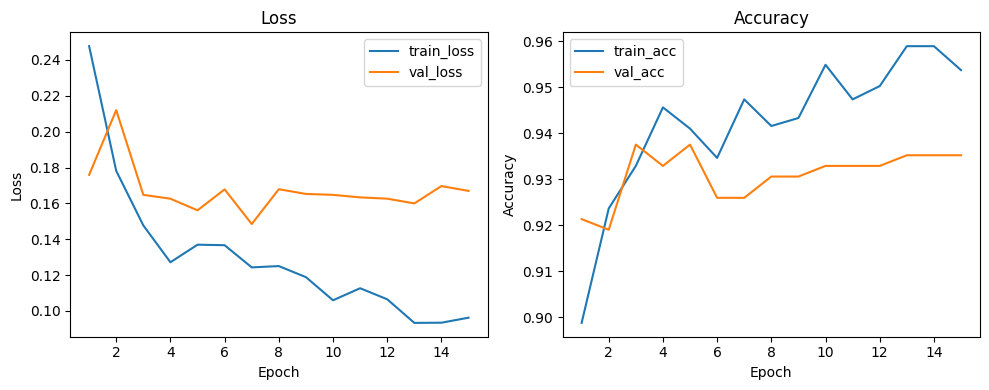

In [75]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Model definition
# -------------------------
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_classes=2, dropout=0.4):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.lin = nn.Linear(hidden_channels * 2, num_classes)  # mean + max concat

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        x = self.dropout(x)
        return self.lin(x)

# -------------------------
# Dataloaders
# -------------------------
train_loader = DataLoader(new_train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(new_test_graphs,  batch_size=32, shuffle=False)

# -------------------------
# Device and model init
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
in_channels = new_train_graphs[0].x.size(1)
model = GraphSAGEClassifier(in_channels, hidden_channels=128, num_classes=2, dropout=0.4).to(device)

# -------------------------
# Loss optimizer scheduler
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# -------------------------
# Mixed precision and training state
# -------------------------
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
best_val_acc = 0.0
best_state = None            # in-memory checkpoint of best model state
patience = 12
stale = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# -------------------------
# Evaluation helper
# -------------------------
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            preds = out.argmax(dim=1)
            correct += (preds == batch.y).sum().item()
            total += batch.y.size(0)
            total_loss += loss.item() * batch.y.size(0)
    return total_loss / total, correct / total

# -------------------------
# Training loop
# -------------------------
num_epochs = 100
for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                out = model(batch.x, batch.edge_index, batch.batch)
                loss = criterion(out, batch.y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

        train_loss += loss.item() * batch.y.size(0)
        preds = out.argmax(dim=1)
        train_correct += (preds == batch.y).sum().item()
        train_total += batch.y.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    val_loss, val_acc = evaluate(model, val_loader)

    # scheduler step on validation accuracy
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:03d}  Train Loss {train_loss:.4f}  Train Acc {train_acc:.4f}  Val Loss {val_loss:.4f}  Val Acc {val_acc:.4f}")

    # in-memory checkpoint and early stopping
    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        stale = 0
        best_state = copy.deepcopy(model.state_dict())
        print("  Saved new best model state in memory")
    else:
        stale += 1
        if stale >= patience:
            print(f"Early stopping after {epoch} epochs (no improvement for {patience} epochs).")
            break

print("Training finished. Best Val Acc:", best_val_acc)

# -------------------------
# Restore best model state for final evaluation
# -------------------------
if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model state from memory for final evaluation")

# -------------------------
# Final evaluation and metrics
# -------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

# -------------------------
# Plot learning curves
# -------------------------
epochs = np.arange(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()
plt.tight_layout()
plt.show()

=== Dataset summary ===
Train graphs: 1728
Val   graphs: 432
Train label distribution: {0: 926, 1: 802}
Val   label distribution: {1: 201, 0: 231}
Nodes per graph: min 1, mean 3.4, max 20
Edges per graph: min 1, mean 7.0, max 71

=== Model parameter summary ===
conv1.lin_l.weight                       | shape: (128, 20)            | params:      2,560 | trainable: True
conv1.lin_l.bias                         | shape: (128,)               | params:        128 | trainable: True
conv1.lin_r.weight                       | shape: (128, 20)            | params:      2,560 | trainable: True
bn1.weight                               | shape: (128,)               | params:        128 | trainable: True
bn1.bias                                 | shape: (128,)               | params:        128 | trainable: True
conv2.lin_l.weight                       | shape: (128, 128)           | params:     16,384 | trainable: True
conv2.lin_l.bias                         | shape: (128,)               | param

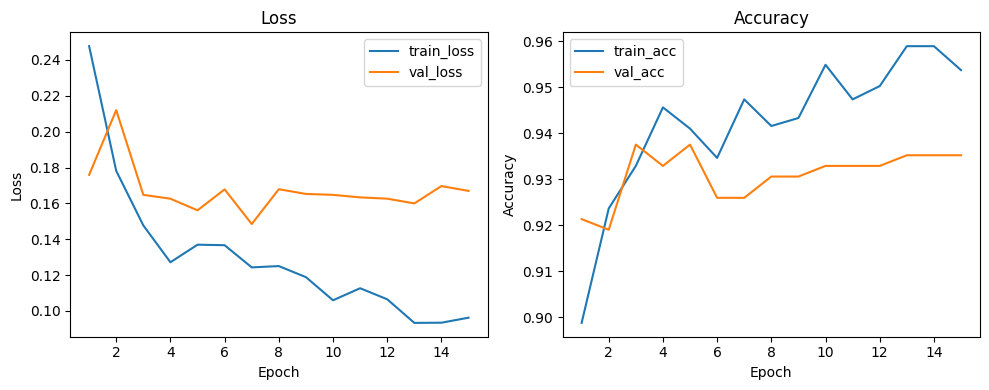


=== Final evaluation ===
Accuracy: 0.9375
Confusion Matrix:
 [[216  15]
 [ 12 189]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9474    0.9351    0.9412       231
           1     0.9265    0.9403    0.9333       201

    accuracy                         0.9375       432
   macro avg     0.9369    0.9377    0.9373       432
weighted avg     0.9376    0.9375    0.9375       432


=== Dataset summary ===
Train graphs: 1728
Val   graphs: 432
Train label distribution: {0: 926, 1: 802}
Val   label distribution: {1: 201, 0: 231}
Nodes per graph: min 1, mean 3.4, max 20
Edges per graph: min 1, mean 7.0, max 71

=== Model parameter summary ===
conv1.lin_l.weight                       | shape: (128, 20)            | params:      2,560 | trainable: True
conv1.lin_l.bias                         | shape: (128,)               | params:        128 | trainable: True
conv1.lin_r.weight                       | shape: (128, 20)            | params: 

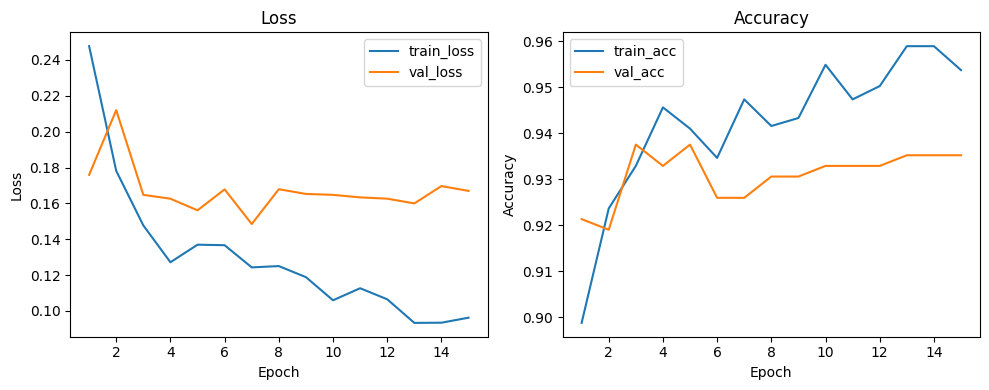


=== Final evaluation ===
Accuracy: 0.9375
Confusion Matrix:
 [[216  15]
 [ 12 189]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9474    0.9351    0.9412       231
           1     0.9265    0.9403    0.9333       201

    accuracy                         0.9375       432
   macro avg     0.9369    0.9377    0.9373       432
weighted avg     0.9376    0.9375    0.9375       432




In [79]:
import torch
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# -------------------------
# 1) Dataset and split summary
# -------------------------
def dataset_summary(train_graphs, val_graphs):
    print("=== Dataset summary ===")
    print(f"Train graphs: {len(train_graphs)}")
    print(f"Val   graphs: {len(val_graphs)}")
    # class distribution
    train_labels = [int(d.y.item()) for d in train_graphs]
    val_labels   = [int(d.y.item()) for d in val_graphs]
    print("Train label distribution:", dict(Counter(train_labels)))
    print("Val   label distribution:", dict(Counter(val_labels)))
    # node/edge stats (min/mean/max)
    node_counts = [g.num_nodes for g in train_graphs + val_graphs]
    edge_counts = [g.num_edges for g in train_graphs + val_graphs]
    print(f"Nodes per graph: min {np.min(node_counts)}, mean {np.mean(node_counts):.1f}, max {np.max(node_counts)}")
    print(f"Edges per graph: min {np.min(edge_counts)}, mean {np.mean(edge_counts):.1f}, max {np.max(edge_counts)}")
    print()

# -------------------------
# 2) Model parameter summary
# -------------------------
def model_param_summary(model):
    print("=== Model parameter summary ===")
    total_params = 0
    trainable_params = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total_params += n
        if p.requires_grad:
            trainable_params += n
        print(f"{name:40s} | shape: {str(tuple(p.shape)):20s} | params: {n:10,d} | trainable: {p.requires_grad}")
    print("-" * 80)
    print(f"Total params: {total_params:,d}")
    print(f"Trainable params: {trainable_params:,d}")
    print()

# -------------------------
# 3) Forward shape trace (one batch) - shows intermediate tensor sizes
# -------------------------
def forward_shape_trace(model, loader, device):
    model.eval()
    print("=== Forward pass shape trace (first batch) ===")
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # attempt to capture shapes before/after convs if model exposes conv layers
            try:
                x = batch.x
                print("batch.x shape:", tuple(x.shape))
                # If model has conv1 and conv2 attributes, show shapes
                if hasattr(model, "conv1"):
                    x1 = model.conv1(x, batch.edge_index)
                    print("after conv1:", tuple(x1.shape))
                if hasattr(model, "conv2"):
                    x2 = model.conv2(x1 if 'x1' in locals() else x, batch.edge_index)
                    print("after conv2:", tuple(x2.shape))
                out = model(batch.x, batch.edge_index, batch.batch)
                print("model output shape:", tuple(out.shape))
            except Exception as e:
                print("Could not run detailed trace (model API mismatch):", e)
                out = model(batch.x, batch.edge_index, batch.batch)
                print("model output shape:", tuple(out.shape))
            break
    print()

# -------------------------
# 4) Training history table and plots
# -------------------------
def show_history(history, save_csv_path=None):
    # history expected keys: train_loss, train_acc, val_loss, val_acc
    df = pd.DataFrame({
        "epoch": np.arange(1, len(history["train_loss"]) + 1),
        "train_loss": history["train_loss"],
        "train_acc": history["train_acc"],
        "val_loss": history["val_loss"],
        "val_acc": history["val_acc"],
    })
    pd.set_option("display.precision", 4)
    print("=== Epoch history (last 10 rows) ===")
    print(df.tail(10).to_string(index=False))
    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"Saved history to: {save_csv_path}")
    # plots
    epochs = df["epoch"].values
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, df["train_loss"], label="train_loss")
    plt.plot(epochs, df["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, df["train_acc"], label="train_acc")
    plt.plot(epochs, df["val_acc"], label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()
    plt.tight_layout()
    plt.show()
    print()

# -------------------------
# 5) Final evaluation summary (confusion matrix + classification report)
# -------------------------
def final_evaluation_report(model, loader, device, labels_map=None):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            preds = out.argmax(dim=1)
            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, digits=4, target_names=None if labels_map is None else [labels_map[i] for i in sorted(labels_map)])
    print("=== Final evaluation ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    print()
    return {"accuracy": acc, "confusion_matrix": cm, "classification_report": cr}

# -------------------------
# 6) Run the full summary
# -------------------------
# Example usage (run these lines after training, with your objects in scope):
dataset_summary(new_train_graphs, new_test_graphs)
model_param_summary(model)
forward_shape_trace(model, train_loader, device)
show_history(history, save_csv_path="training_history.csv")
final_evaluation_report(model, val_loader, device)

# If you want to run all at once:
def full_report(model, train_graphs, val_graphs, train_loader, val_loader, history, device, save_history_csv="training_history.csv", labels_map=None):
    dataset_summary(train_graphs, val_graphs)
    model_param_summary(model)
    forward_shape_trace(model, train_loader, device)
    show_history(history, save_csv_path=save_history_csv)
    metrics = final_evaluation_report(model, val_loader, device, labels_map=labels_map)
    return metrics

# Example call (uncomment to run):
metrics = full_report(model, new_train_graphs, new_test_graphs, train_loader, val_loader, history, device)

In [84]:
# Combined pipeline: augmentations -> GraphCL pretrain -> fine-tune -> ensemble -> TTA eval
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------
# Hyperparameters (tune these)
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRETRAIN_EPOCHS = 80
PRETRAIN_BS = 128
PRETRAIN_LR = 1e-3
FINETUNE_EPOCHS = 40
FINETUNE_BS = 32
FINETUNE_LR = 1e-3
ENSEMBLE_SIZE = 3
TTA_K = 5
SEEDS = [0, 1, 2, 3, 4]

# -------------------------
# Augmentations
# -------------------------
def edge_dropout(data: Data, p=0.2):
    ei = data.edge_index
    m = ei.size(1)
    mask = torch.rand(m, device=ei.device) > p
    new = copy.copy(data)
    new.edge_index = ei[:, mask]
    return new

def feature_masking(data: Data, p=0.1):
    x = data.x.clone()
    mask = torch.rand(x.size(), device=x.device) < p
    x[mask] = 0.0
    new = copy.copy(data)
    new.x = x
    return new

def node_attr_jitter(data: Data, sigma=0.01):
    x = data.x.clone()
    noise = torch.randn_like(x) * sigma
    new = copy.copy(data)
    new.x = x + noise
    return new

def graph_augment(data: Data):
    # choose one augmentation randomly with slight param variation
    aug = random.choice([edge_dropout, feature_masking, node_attr_jitter])
    if aug is edge_dropout:
        return edge_dropout(data, p=random.uniform(0.08, 0.25))
    if aug is feature_masking:
        return feature_masking(data, p=random.uniform(0.03, 0.15))
    return node_attr_jitter(data, sigma=random.uniform(0.003, 0.02))

# -------------------------
# Encoder and classifier definitions
# -------------------------
class GraphEncoder(nn.Module):
    def __init__(self, in_channels, hidden=128):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.proj = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        g = global_mean_pool(x, batch)
        z = self.proj(g)
        z = F.normalize(z, dim=1)
        return z

class GraphClassifier(nn.Module):
    def __init__(self, encoder, hidden=128, num_classes=2, dropout=0.4):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes)
        )

    def forward(self, x, edge_index, batch):
        z = self.encoder(x, edge_index, batch)
        return self.head(z)

# -------------------------
# Contrastive loss (NT-Xent)
# -------------------------
def nt_xent_loss(z1, z2, temperature=0.2):
    z = torch.cat([z1, z2], dim=0)  # 2N x D
    sim = torch.matmul(z, z.T) / temperature
    N = z1.size(0)
    labels = torch.arange(N, device=z.device)
    positives = torch.exp(torch.sum(z1 * z2, dim=1) / temperature)
    positives = torch.cat([positives, positives], dim=0)
    mask = (~torch.eye(2*N, dtype=torch.bool, device=z.device)).float()
    exp_sim = torch.exp(sim) * mask
    denom = exp_sim.sum(dim=1)
    loss = -torch.log(positives / denom)
    return loss.mean()

# -------------------------
# Pretraining: GraphCL style
# -------------------------
def pretrain_graphcl(encoder, graphs, device=DEVICE, epochs=PRETRAIN_EPOCHS, batch_size=PRETRAIN_BS, lr=PRETRAIN_LR):
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=True)
    encoder = encoder.to(device)
    opt = torch.optim.Adam(encoder.parameters(), lr=lr, weight_decay=1e-5)
    for epoch in range(1, epochs + 1):
        encoder.train()
        total_loss = 0.0
        total_samples = 0
        for batch in loader:
            # create two augmentations per graph in the batch
            g_list = batch.to_data_list()
            g1 = [graph_augment(d) for d in g_list]
            g2 = [graph_augment(d) for d in g_list]
            b1 = Batch.from_data_list(g1).to(device)
            b2 = Batch.from_data_list(g2).to(device)
            z1 = encoder(b1.x, b1.edge_index, b1.batch)
            z2 = encoder(b2.x, b2.edge_index, b2.batch)
            loss = nt_xent_loss(z1, z2)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * z1.size(0)
            total_samples += z1.size(0)
        avg = total_loss / max(1, total_samples)
        if epoch % 10 == 0 or epoch == 1:
            print(f"[Pretrain] Epoch {epoch:03d}  Loss {avg:.4f}")
    return encoder

# -------------------------
# Fine-tune classifier
# -------------------------
def finetune_classifier(encoder, train_graphs, val_graphs, device=DEVICE,
                        epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BS, lr=FINETUNE_LR,
                        weight_decay=1e-4, freeze_encoder_epochs=2):
    model = GraphClassifier(encoder).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    best_acc = 0.0
    best_state = None

    # optionally freeze encoder for a few epochs
    for p in model.encoder.parameters():
        p.requires_grad = False
    for epoch in range(1, epochs + 1):
        if epoch > freeze_encoder_epochs:
            for p in model.encoder.parameters():
                p.requires_grad = True

        model.train()
        t_correct = 0
        t_total = 0
        for batch in train_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = nn.CrossEntropyLoss()(out, batch.y)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
            preds = out.argmax(dim=1)
            t_correct += (preds == batch.y).sum().item()
            t_total += batch.y.size(0)

        # validation
        model.eval()
        v_correct = 0
        v_total = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.batch)
                preds = out.argmax(dim=1)
                v_correct += (preds == batch.y).sum().item()
                v_total += batch.y.size(0)
        val_acc = v_correct / v_total
        scheduler.step(val_acc)
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        if epoch % 5 == 0 or epoch == 1:
            print(f"[Finetune] Epoch {epoch:03d}  TrainAcc {t_correct/t_total:.4f}  ValAcc {val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_acc

# -------------------------
# Ensemble training wrapper
# -------------------------
def train_ensemble(n_models, train_graphs, val_graphs, device=DEVICE, seeds=SEEDS):
    models = []
    for i in range(n_models):
        seed = seeds[i % len(seeds)]
        torch.manual_seed(seed)
        random.seed(seed)
        # fresh encoder
        in_ch = train_graphs[0].x.size(1)
        enc = GraphEncoder(in_channels=in_ch, hidden=128)
        print(f"\n=== Model {i} pretraining (seed {seed}) ===")
        enc = pretrain_graphcl(enc, train_graphs, device=device, epochs=PRETRAIN_EPOCHS, batch_size=PRETRAIN_BS, lr=PRETRAIN_LR)
        print(f"=== Model {i} fine-tuning ===")
        model, acc = finetune_classifier(enc, train_graphs, val_graphs, device=device,
                                         epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BS, lr=FINETUNE_LR)
        print(f"Model {i} best val acc: {acc:.4f}")
        models.append(model)
    return models

# -------------------------
# TTA predict for a single batch (averaging logits)
# -------------------------
def tta_batch_predict(models, batch, device=DEVICE, k=TTA_K):
    batch = batch.to(device)
    logits_sum = None
    for m in models:
        m.eval()
    with torch.no_grad():
        for _ in range(k):
            # apply augmentation per graph in batch
            g_list = batch.to_data_list()
            aug_list = [graph_augment(g) for g in g_list]
            aug_batch = Batch.from_data_list(aug_list).to(device)
            logits = None
            for m in models:
                out = m(aug_batch.x, aug_batch.edge_index, aug_batch.batch)
                logits = out if logits is None else logits + out
            logits = logits / len(models)
            logits_sum = logits if logits_sum is None else logits_sum + logits
    avg_logits = logits_sum / k
    preds = avg_logits.argmax(dim=1).cpu().numpy()
    return preds

# -------------------------
# Ensemble evaluation with TTA
# -------------------------
def evaluate_ensemble_tta(models, test_graphs, device=DEVICE, batch_size=32, k=TTA_K):
    loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)
    y_true = []
    y_pred = []
    for batch in loader:
        # original labels
        y_true.extend(batch.y.cpu().numpy())
        preds = tta_batch_predict(models, batch, device=device, k=k)
        y_pred.extend(preds)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, digits=4)
    print("=== Ensemble TTA Results ==")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    return {"accuracy": acc, "confusion_matrix": cm, "classification_report": cr}

# -------------------------
# Run full pipeline
# -------------------------
def run_full_pipeline():
    print("Starting ensemble training pipeline")
    # Use new_train_graphs and new_test_graphs which contain the 80/20 split
    models = train_ensemble(ENSEMBLE_SIZE, new_train_graphs, new_test_graphs, device=DEVICE, seeds=SEEDS)
    print("\nEvaluating ensemble with TTA")
    results = evaluate_ensemble_tta(models, new_test_graphs, device=DEVICE, batch_size=32, k=TTA_K)
    return models, results

# Execute
if __name__ == "__main__":
    models, results = run_full_pipeline()
    # optionally save models to disk
    for i, m in enumerate(models):
        torch.save(m.state_dict(), f"ensemble_model_{i}.pt")
    print("Pipeline complete. Models saved: ensemble_model_0.pt ...")

Starting ensemble training pipeline

=== Model 0 pretraining (seed 0) ===
[Pretrain] Epoch 001  Loss 2.8682
[Pretrain] Epoch 010  Loss 1.8555
[Pretrain] Epoch 020  Loss 1.7831
[Pretrain] Epoch 030  Loss 1.7411
[Pretrain] Epoch 040  Loss 1.7081
[Pretrain] Epoch 050  Loss 1.6894
[Pretrain] Epoch 060  Loss 1.6935
[Pretrain] Epoch 070  Loss 1.6604
[Pretrain] Epoch 080  Loss 1.6652
=== Model 0 fine-tuning ===
[Finetune] Epoch 001  TrainAcc 0.6696  ValAcc 0.8426
[Finetune] Epoch 005  TrainAcc 0.9508  ValAcc 0.9167
[Finetune] Epoch 010  TrainAcc 0.9583  ValAcc 0.9444
[Finetune] Epoch 015  TrainAcc 0.9606  ValAcc 0.9398
[Finetune] Epoch 020  TrainAcc 0.9618  ValAcc 0.9375
[Finetune] Epoch 025  TrainAcc 0.9676  ValAcc 0.9329
[Finetune] Epoch 030  TrainAcc 0.9682  ValAcc 0.9329
[Finetune] Epoch 035  TrainAcc 0.9699  ValAcc 0.9329
[Finetune] Epoch 040  TrainAcc 0.9688  ValAcc 0.9329
Model 0 best val acc: 0.9444

=== Model 1 pretraining (seed 1) ===
[Pretrain] Epoch 001  Loss 2.8827
[Pretrain] Epo